# Iterative AutoMetrics Analysis: Press Release (VLLM 70B)

Analysis of the iterative contrastive AutoMetrics pipeline run on press release data
using `meta-llama/Llama-3.3-70B-Instruct` via VLLM offline backend.

**Output dir**: `outputs/iterative_autometrics/press_release_vllm_70b/`

### Terminology

- **Metric**: A named evaluation dimension (e.g., "Clarity_of_Purpose"). Each metric has
  a 5-level **rubric** that describes what scores 1–5 look like for that dimension.
  They are stored together in a `MetricSpec` dataclass: the metric is the concept,
  the rubric is the scoring guide.
- **Seed** (pair method): At iteration 0, there is no model to identify confusing pairs,
  so pairs are drawn by randomly sampling one positive and one negative example.
  From iteration 1+, the method switches to **propensity matching** (pairs with similar
  predicted probabilities but opposite true labels) or **residual selection** (hardest
  misclassified examples).
- **Interaction terms**: Pairwise products of metric scores (A × B) included as features
  in the L1 logistic regression. L1 selects which interactions are meaningful. Active
  interactions are named by the LLM and shown to the proposer.

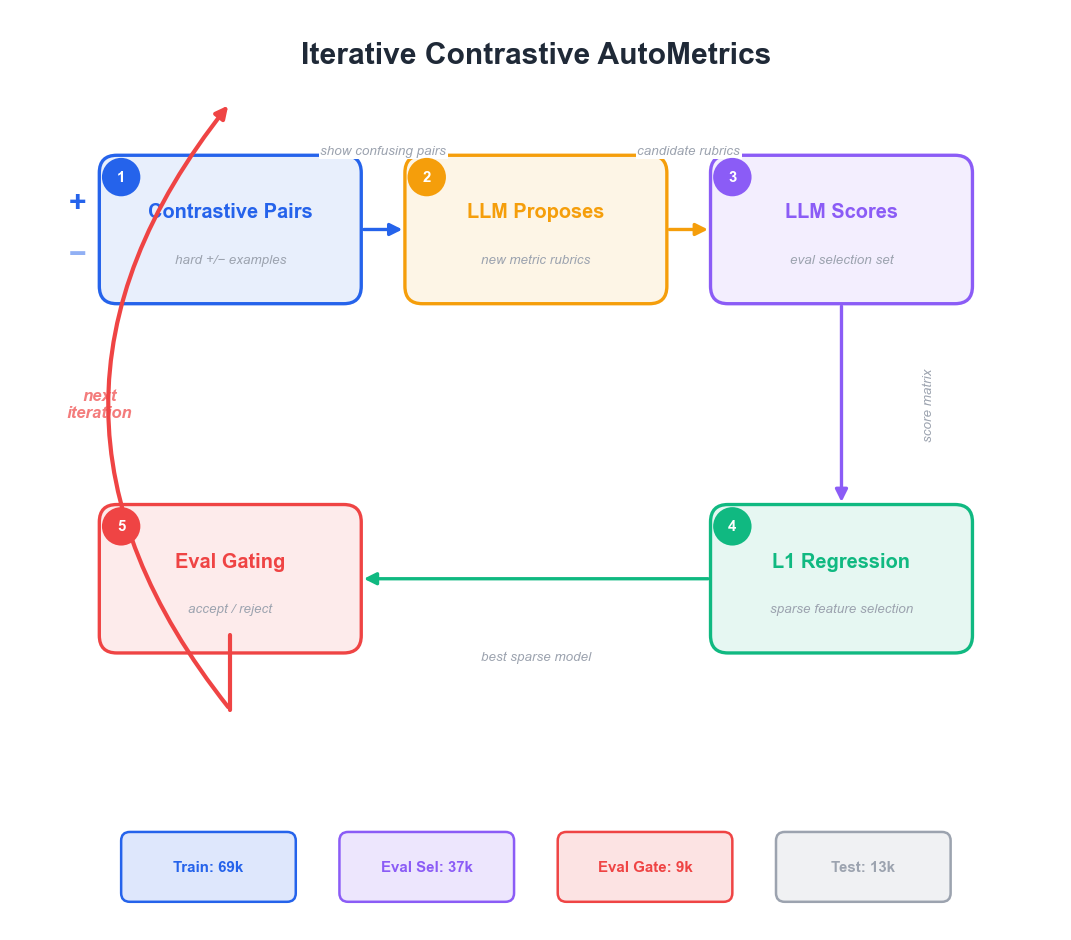

In [110]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle
import matplotlib.colors as mcolors
import numpy as np

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(-1, 11)
ax.set_ylim(-1.5, 9)
ax.set_aspect('equal')
ax.axis('off')
fig.patch.set_facecolor('white')

# ── Colors ──
PAL = {
    'pairs':  '#2563EB',  # blue
    'llm':    '#F59E0B',  # amber
    'score':  '#8B5CF6',  # violet
    'reg':    '#10B981',  # emerald
    'gate':   '#EF4444',  # red
    'text':   '#1F2937',  # dark gray
    'muted':  '#9CA3AF',  # medium gray
    'light':  '#F3F4F6',  # light gray
}

def rgba(hex_color, a=0.12):
    r, g, b = mcolors.to_rgb(hex_color)
    return (r, g, b, a)

# ── Drawing helpers ──
def rounded_box(cx, cy, w, h, color, label, sub=None, fontsize=12):
    bx = FancyBboxPatch((cx - w/2, cy - h/2), w, h,
                        boxstyle="round,pad=0.2", lw=2,
                        edgecolor=color, facecolor=rgba(color, 0.10))
    ax.add_patch(bx)
    if sub:
        ax.text(cx, cy + 0.2, label, ha='center', va='center',
                fontsize=fontsize, fontweight='bold', color=color)
        ax.text(cx, cy - 0.35, sub, ha='center', va='center',
                fontsize=8, color=PAL['muted'], fontstyle='italic')
    else:
        ax.text(cx, cy, label, ha='center', va='center',
                fontsize=fontsize, fontweight='bold', color=color)

def draw_arrow(x1, y1, x2, y2, color=PAL['muted'], lw=2, shrinkA=12, shrinkB=12):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='-|>', color=color, lw=lw,
                                shrinkA=shrinkA, shrinkB=shrinkB,
                                mutation_scale=15))

def edge_label(x, y, text, rotation=0):
    ax.text(x, y, text, ha='center', va='center', fontsize=8,
            color=PAL['muted'], fontstyle='italic', rotation=rotation,
            bbox=dict(facecolor='white', edgecolor='none', pad=1))

# ── Step numbers ──
def step_num(cx, cy, n, color):
    c = Circle((cx, cy), 0.22, fc=color, ec='none', zorder=5)
    ax.add_patch(c)
    ax.text(cx, cy, str(n), ha='center', va='center', fontsize=9,
            fontweight='bold', color='white', zorder=6)

# ── Layout: rectangular loop ──
# Positions
x_left, x_mid, x_right = 1.5, 5.0, 8.5
y_top, y_bot = 6.5, 2.5
bw, bh = 2.6, 1.3

# ── Boxes ──
rounded_box(x_left, y_top, bw, bh, PAL['pairs'],
            'Contrastive Pairs', sub='hard +/\u2212 examples')
rounded_box(x_mid, y_top, bw, bh, PAL['llm'],
            'LLM Proposes', sub='new metric rubrics')
rounded_box(x_right, y_top, bw, bh, PAL['score'],
            'LLM Scores', sub='eval selection set')
rounded_box(x_right, y_bot, bw, bh, PAL['reg'],
            'L1 Regression', sub='sparse feature selection')
rounded_box(x_left, y_bot, bw, bh, PAL['gate'],
            'Eval Gating', sub='accept / reject')

# ── Step numbers ──
step_num(x_left - bw/2 + 0.05, y_top + bh/2 - 0.05, 1, PAL['pairs'])
step_num(x_mid - bw/2 + 0.05, y_top + bh/2 - 0.05, 2, PAL['llm'])
step_num(x_right - bw/2 + 0.05, y_top + bh/2 - 0.05, 3, PAL['score'])
step_num(x_right - bw/2 + 0.05, y_bot + bh/2 - 0.05, 4, PAL['reg'])
step_num(x_left - bw/2 + 0.05, y_bot + bh/2 - 0.05, 5, PAL['gate'])

# ── Arrows ──
draw_arrow(x_left + bw/2, y_top, x_mid - bw/2, y_top, PAL['pairs'])
draw_arrow(x_mid + bw/2, y_top, x_right - bw/2, y_top, PAL['llm'])
draw_arrow(x_right, y_top - bh/2, x_right, y_bot + bh/2, PAL['score'])
draw_arrow(x_right - bw/2, y_bot, x_left + bw/2, y_bot, PAL['reg'])

# Loop-back arrow (gate -> pairs): go down, left, and up
loop_y = 1.0
ax.plot([x_left, x_left], [y_bot - bh/2, loop_y], color=PAL['gate'], lw=2.5, solid_capstyle='round')
ax.plot([x_left, x_left], [loop_y, loop_y], color=PAL['gate'], lw=2.5, solid_capstyle='round')
ax.annotate('', xy=(x_left, y_top + bh/2 + 0.8), xytext=(x_left, loop_y),
            arrowprops=dict(arrowstyle='-|>', color=PAL['gate'], lw=2.5,
                            mutation_scale=15,
                            connectionstyle='arc3,rad=-0.4'))

# ── Edge labels ──
edge_label((x_left + x_mid) / 2, y_top + 0.9, 'show confusing pairs')
edge_label((x_mid + x_right) / 2, y_top + 0.9, 'candidate rubrics')
edge_label(x_right + 1.0, (y_top + y_bot) / 2, 'score matrix', rotation=90)
edge_label((x_left + x_right) / 2, y_bot - 0.9, 'best sparse model')

# ── Loop label ──
ax.text(x_left - 1.5, (y_top + y_bot) / 2, 'next\niteration',
        ha='center', va='center', fontsize=10, color=PAL['gate'],
        fontweight='bold', fontstyle='italic', alpha=0.7)

# ── Small +/- icons next to pairs box ──
for dy, sym, alpha in [(0.3, '+', 1.0), (-0.3, '\u2212', 0.5)]:
    ax.text(x_left - bw/2 - 0.45, y_top + dy, sym, fontsize=18,
            fontweight='bold', color=PAL['pairs'], alpha=alpha,
            ha='center', va='center')

# ── Title ──
ax.text(5.0, 8.5, 'Iterative Contrastive AutoMetrics',
        fontsize=18, fontweight='bold', ha='center', va='center',
        color=PAL['text'])

# ── Data split legend at bottom ──
split_y = -0.8
splits = [
    ('Train', '69k', PAL['pairs']),
    ('Eval Sel', '37k', PAL['score']),
    ('Eval Gate', '9k', PAL['gate']),
    ('Test', '13k', PAL['muted']),
]
total_w = len(splits) * 2.5
start_x = 5.0 - total_w / 2 + 1.25
for i, (name, n, color) in enumerate(splits):
    sx = start_x + i * 2.5
    r = FancyBboxPatch((sx - 0.9, split_y - 0.3), 1.8, 0.6,
                       boxstyle="round,pad=0.1", lw=1.5,
                       edgecolor=color, facecolor=rgba(color, 0.15))
    ax.add_patch(r)
    ax.text(sx, split_y, f'{name}: {n}', ha='center', va='center',
            fontsize=9, fontweight='bold', color=color)

plt.tight_layout()
plt.savefig('../outputs/iterative_autometrics/autometrics_flow.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

In [78]:
# Pull latest data from server (run this cell to refresh)
!rsync -avz --progress \
    sk3:/lfs/skampere3/0/alexspan/norm-research/outputs/iterative_autometrics/press_release_vllm_70b/ \
    ../outputs/iterative_autometrics/press_release_vllm_70b/

receiving incremental file list
label_cache/108ce218a3e0ef44c8e2ef96e9fb60ddd9b8b142.csv
         25,287 100%   24.12MB/s    0:00:00 (xfr#1, to-chk=48/64)
label_cache/13b5a18429661c9aca138d8327a36689efb43a09.csv
         25,287 100%   24.12MB/s    0:00:00 (xfr#2, to-chk=45/64)
label_cache/22a656e28e407092e65e596f4ffee2b0302b626b.csv
         25,287 100%   12.06MB/s    0:00:00 (xfr#3, to-chk=42/64)
label_cache/438a2c3bcbe432b117783f38817ff7902723ddc7.csv
         25,287 100%    8.04MB/s    0:00:00 (xfr#4, to-chk=33/64)
label_cache/43bd3880bfb7db61418bfc3cf6bd76702237a905.csv
         25,287 100%    6.03MB/s    0:00:00 (xfr#5, to-chk=32/64)
label_cache/bb9a2e005dba6698bcf4677fbf1c054b52a96d56.csv
         25,287 100%    6.03MB/s    0:00:00 (xfr#6, to-chk=11/64)

sent 1,255 bytes  received 6,416 bytes  5,114.00 bytes/sec
total size is 2,141,763  speedup is 279.20


In [104]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from textwrap import fill

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

OUTPUT_DIR = Path("../outputs/iterative_autometrics/press_release_vllm_70b")
assert OUTPUT_DIR.exists(), f"Output dir not found: {OUTPUT_DIR}"

## 1. Load Data

The output files may contain duplicate entries from earlier pipeline runs that
shared the same output directory. We deduplicate by keeping only the **last**
complete run (i.e., the last occurrence of each iteration number).

In [111]:
# --- helpers ---
def load_jsonl(path):
    """Load a JSONL file, returning a list of dicts."""
    records = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

def dedup_last_run(records, key="iteration"):
    """
    Multiple runs may have appended to the same file.
    Identify the last run by finding the final 'iteration 0' entry,
    then taking everything from that point forward.
    """
    # Find the index of the last iteration-0 entry
    last_start = 0
    for i, rec in enumerate(records):
        if rec.get(key) == 0:
            last_start = i
    # Take the last run's entries and dedup within it
    last_run = records[last_start:]
    seen = {}
    for rec in last_run:
        seen[rec[key]] = rec
    return [seen[k] for k in sorted(seen.keys())]

In [112]:
# --- config ---
with open(OUTPUT_DIR / "config.json") as f:
    config = json.load(f)
print(json.dumps(config, indent=2))

{
  "num_iterations": 25,
  "matching_only": false,
  "residual_only": false,
  "split_dir": "/lfs/skampere3/0/alexspan/norm-research/datasets/press-releases/press_release_modeling_dataset.csv",
  "data_path": "/lfs/skampere3/0/alexspan/norm-research/datasets/press-releases/press_release_modeling_dataset.csv/train.csv.gz",
  "target_measure": "newsworthiness_score",
  "id_column": "press_release_id",
  "text_column": "text",
  "label_column": "judgement",
  "output_dir": "/lfs/skampere3/0/alexspan/norm-research/outputs/iterative_autometrics/press_release_vllm_70b",
  "k_pairs": 5,
  "num_metrics": 5,
  "num_rubrics": 5,
  "caliper": 0.1,
  "label_batch_size": 200,
  "eval_gate_fraction": 0.2,
  "eval_fraction": 0.4,
  "max_text_tokens": 512,
  "tqdm_scoring": true,
  "llm_parallelism": 1,
  "seed": 42,
  "churn_warning_threshold": 0.5,
  "min_tenure": 0,
  "verbose": true,
  "early_stop_patience": 2,
  "disable_early_stopping": true,
  "use_interactions": true
}


In [113]:
# --- iterations ---
iterations_raw = load_jsonl(OUTPUT_DIR / "iterations.jsonl")
iterations = dedup_last_run(iterations_raw)
iterations_df = pd.json_normalize(iterations)
print(f"Loaded {len(iterations_raw)} raw records -> {len(iterations)} unique iterations (0..{iterations[-1]['iteration']})")
iterations_df.head()

Loaded 48 raw records -> 25 unique iterations (0..24)


,iteration,active_metric_ids,active_metric_names,gate_metric,eval_gate_score,accepted,num_active_metrics,num_active_interactions,eval_selection.accuracy,eval_selection.precision,...,active_interactions.Cultural_and_Social_Sensitivity × Measurable_Outcomes_and_ROI.coef,active_interactions.Cultural_and_Social_Sensitivity × Measurable_Outcomes_and_ROI.desc,active_interactions.Cultural_and_Social_Sensitivity × Content_Originality_and_Uniqueness.a,active_interactions.Cultural_and_Social_Sensitivity × Content_Originality_and_Uniqueness.b,active_interactions.Cultural_and_Social_Sensitivity × Content_Originality_and_Uniqueness.coef,active_interactions.Cultural_and_Social_Sensitivity × Content_Originality_and_Uniqueness.desc,active_interactions.Measurable_Outcomes_and_ROI × Content_Originality_and_Uniqueness.a,active_interactions.Measurable_Outcomes_and_ROI × Content_Originality_and_Uniqueness.b,active_interactions.Measurable_Outcomes_and_ROI × Content_Originality_and_Uniqueness.coef,active_interactions.Measurable_Outcomes_and_ROI × Content_Originality_and_Uniqueness.desc
0,0,"[f4ee378ac62460b09cbb529ff8559407f9ae3722, b2f...","[Factual_Specificity, Societal_Impact_Scope, S...",roc_auc,0.558184,True,5,9,0.580933,0.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,"[f4ee378ac62460b09cbb529ff8559407f9ae3722, b2f...","[Factual_Specificity, Societal_Impact_Scope, S...",roc_auc,0.562555,True,9,9,0.580608,0.484536,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,"[f4ee378ac62460b09cbb529ff8559407f9ae3722, b2f...","[Factual_Specificity, Societal_Impact_Scope, S...",roc_auc,0.565828,True,11,30,0.581231,0.505345,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,"[f4ee378ac62460b09cbb529ff8559407f9ae3722, b2f...","[Factual_Specificity, Societal_Impact_Scope, S...",roc_auc,0.564815,True,12,41,0.580879,0.499038,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,"[f4ee378ac62460b09cbb529ff8559407f9ae3722, b2f...","[Factual_Specificity, Societal_Impact_Scope, S...",roc_auc,0.563069,True,13,47,0.580906,0.499569,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [114]:
# --- eval & test metrics ---
eval_metrics = pd.DataFrame(dedup_last_run(load_jsonl(OUTPUT_DIR / "eval_metrics.jsonl")))
test_metrics = pd.DataFrame(dedup_last_run(load_jsonl(OUTPUT_DIR / "test_metrics.jsonl")))

print(f"Eval metrics: {len(eval_metrics)} iterations")
print(f"Test metrics: {len(test_metrics)} iterations")

Eval metrics: 25 iterations
Test metrics: 25 iterations


In [115]:
# --- coefficients ---
# NOTE: coefficients.csv may be from an earlier run if the output directory
# was reused. Cross-check metric names with iterations.jsonl.
coefficients_df = pd.read_csv(OUTPUT_DIR / "coefficients.csv")
coef_metric_names = set(coefficients_df["name"].unique())
iter_metric_names = set()
for it in iterations:
    iter_metric_names.update(it.get("active_metric_names", []))

if coef_metric_names & iter_metric_names:
    print(f"Coefficients: {len(coefficients_df)} rows, iterations {sorted(coefficients_df.iteration.unique())}")
else:
    print(f"WARNING: coefficients.csv appears to be from a different run.")
    print(f"  coefficients.csv metrics: {list(coef_metric_names)[:3]}...")
    print(f"  iterations.jsonl metrics: {list(iter_metric_names)[:3]}...")
    print(f"  Coefficient plots below may not match the current run.")
coefficients_df.head(10)

Coefficients: 497 rows, iterations [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


,iteration,metric_id,name,coefficient
0,0,f4ee378ac62460b09cbb529ff8559407f9ae3722,Factual_Specificity,-0.241322
1,0,b2f903016efeab61d270bcb3fabe0a4c25dd45fb,Societal_Impact_Scope,0.037282
2,0,1720f827c169584e4377cbf05e332f47d2d653dc,Source_Credibility,0.025368
3,0,86b364a8b15efe01a4e08138ba3f053d800a7e38,Novelty_of_Announcement,0.885060
4,0,71992c69616df327d01dbfe40e5ec3b8f0f4e6a8,Data_Evidence_Backing_Claims,-0.375591
5,1,f4ee378ac62460b09cbb529ff8559407f9ae3722,Factual_Specificity,-0.133031
6,1,b2f903016efeab61d270bcb3fabe0a4c25dd45fb,Societal_Impact_Scope,0.000000
7,1,1720f827c169584e4377cbf05e332f47d2d653dc,Source_Credibility,0.011266
8,1,86b364a8b15efe01a4e08138ba3f053d800a7e38,Novelty_of_Announcement,0.882890
9,1,71992c69616df327d01dbfe40e5ec3b8f0f4e6a8,Data_Evidence_Backing_Claims,-0.612782


In [116]:
# --- metrics catalog ---
# metrics.csv may be from an earlier run. Build metric lifecycle from iterations.jsonl
# which is authoritative for the current (dedup'd) run.
metrics_csv_path = OUTPUT_DIR / "metrics.csv"
if metrics_csv_path.exists():
    metrics_df_csv = pd.read_csv(metrics_csv_path)
    print(f"metrics.csv: {len(metrics_df_csv)} rows (may be from earlier run)")
else:
    metrics_df_csv = pd.DataFrame()

# Build metric lifecycle from iterations.jsonl
metric_lifecycle = {}  # name -> {born, active_iters, retired}
for it in iterations:
    for name in it.get("active_metric_names", []):
        if name not in metric_lifecycle:
            metric_lifecycle[name] = {
                "born_iteration": it["iteration"],
                "active_iterations": [],
                "retired_iteration": None,
            }
        metric_lifecycle[name]["active_iterations"].append(it["iteration"])

# Detect retirements
final_active = set(iterations[-1].get("active_metric_names", []))
for name, info in metric_lifecycle.items():
    if name not in final_active:
        info["retired_iteration"] = max(info["active_iterations"]) + 1

metrics_df = pd.DataFrame([
    {"name": name, **info} for name, info in metric_lifecycle.items()
])

# Add rubric_text from metrics.csv if names match
if len(metrics_df_csv) > 0 and "rubric_text" in metrics_df_csv.columns:
    rubric_map = dict(zip(metrics_df_csv["name"], metrics_df_csv["rubric_text"]))
    metrics_df["rubric_text"] = metrics_df["name"].map(rubric_map).fillna("")
else:
    metrics_df["rubric_text"] = ""

# Also try to get rubric text from iterations.jsonl metric_specs if available
for it in iterations:
    for spec in it.get("metric_specs", []):
        name = spec.get("name", "")
        rubric = spec.get("rubric_text", "")
        if name and rubric and name in metric_lifecycle:
            if metrics_df.loc[metrics_df["name"] == name, "rubric_text"].iloc[0] == "":
                metrics_df.loc[metrics_df["name"] == name, "rubric_text"] = rubric

print(f"Total unique metrics (from iterations.jsonl): {len(metrics_df)}")
print(f"Final active: {len(final_active)}")
metrics_df[["name", "born_iteration", "active_iterations", "retired_iteration"]]

metrics.csv: 26 rows (may be from earlier run)
Total unique metrics (from iterations.jsonl): 26
Final active: 26


,name,born_iteration,active_iterations,retired_iteration
0,Factual_Specificity,0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",None
1,Societal_Impact_Scope,0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",None
2,Source_Credibility,0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",None
3,Novelty_of_Announcement,0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",None
4,Data_Evidence_Backing_Claims,0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",None
5,Timeliness_and_Relevance,1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",None
6,Transparency_and_Accountability,1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",None
7,Audience_Relevance,1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",None
8,Institutional_Significance,1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",None
9,Long_Term_Impact_Potential,2,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 1...",None


In [117]:
# --- pairs ---
pairs_raw = load_jsonl(OUTPUT_DIR / "pairs.jsonl")
pairs_df = pd.DataFrame(pairs_raw)
# Deduplicate: keep only the last set of pairs per iteration
# Group by iteration and take the last k_pairs entries
pairs_deduped = pairs_df.groupby("iteration").tail(config.get("k_pairs", 5)).reset_index(drop=True)
print(f"Pairs: {len(pairs_raw)} raw -> {len(pairs_deduped)} deduped")

Pairs: 215 raw -> 125 deduped


## 2. Eval & Test Performance Across Iterations

Track how the classifier improves (or not) as new metrics are discovered and added.

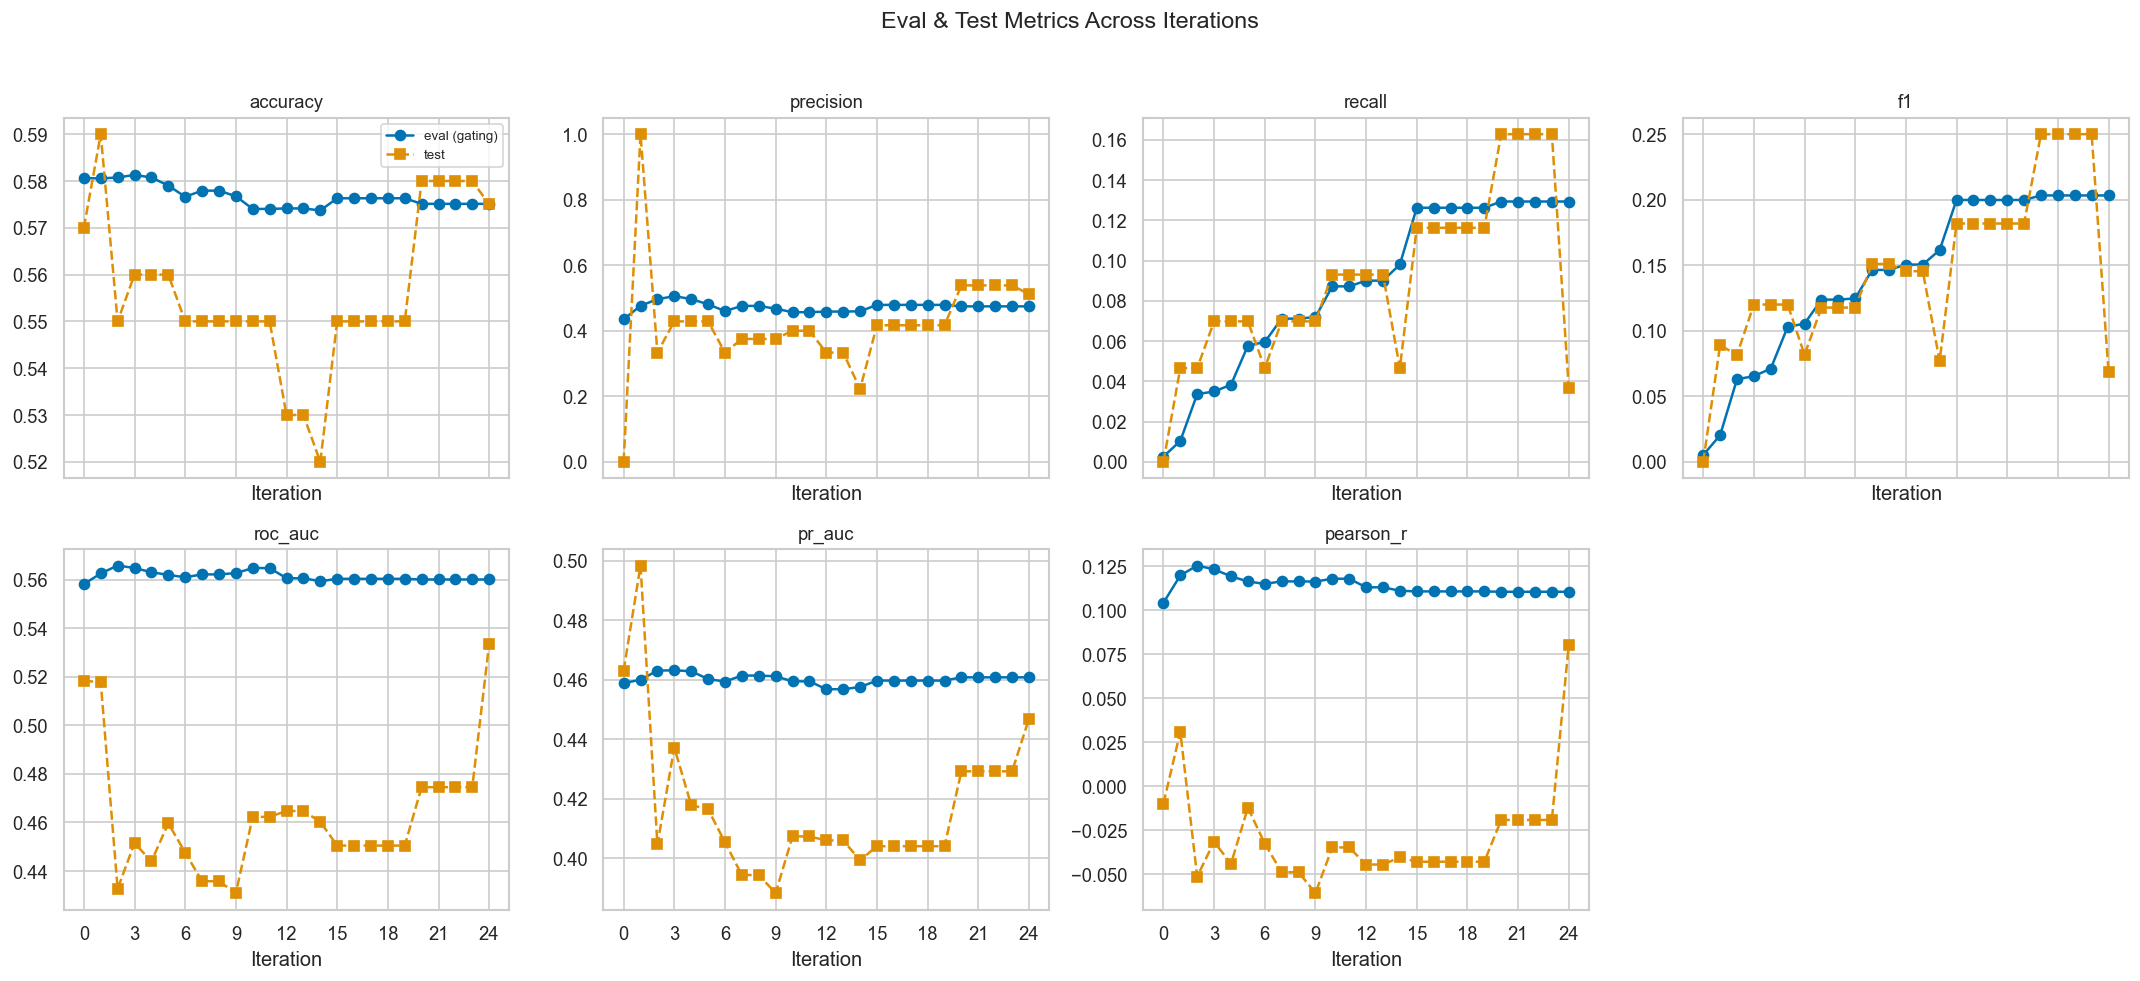

In [118]:
score_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "pearson_r"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True)
axes = axes.flatten()

for i, col in enumerate(score_cols):
    ax = axes[i]
    if col in eval_metrics.columns:
        ax.plot(eval_metrics["iteration"], eval_metrics[col], "o-", label="eval (gating)", color="C0")
    if col in test_metrics.columns:
        ax.plot(test_metrics["iteration"], test_metrics[col], "s--", label="test", color="C1")
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("Iteration")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    if i == 0:
        ax.legend(fontsize=8)

# hide unused subplot
axes[-1].set_visible(False)

fig.suptitle("Eval & Test Metrics Across Iterations", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 3. Eval Selection vs. Eval Gating Performance

The pipeline uses a **selection** eval set to pick the best metric subset via logistic regression,
then validates on a held-out **gating** eval set to decide whether to accept.
Comparing these reveals potential overfitting.

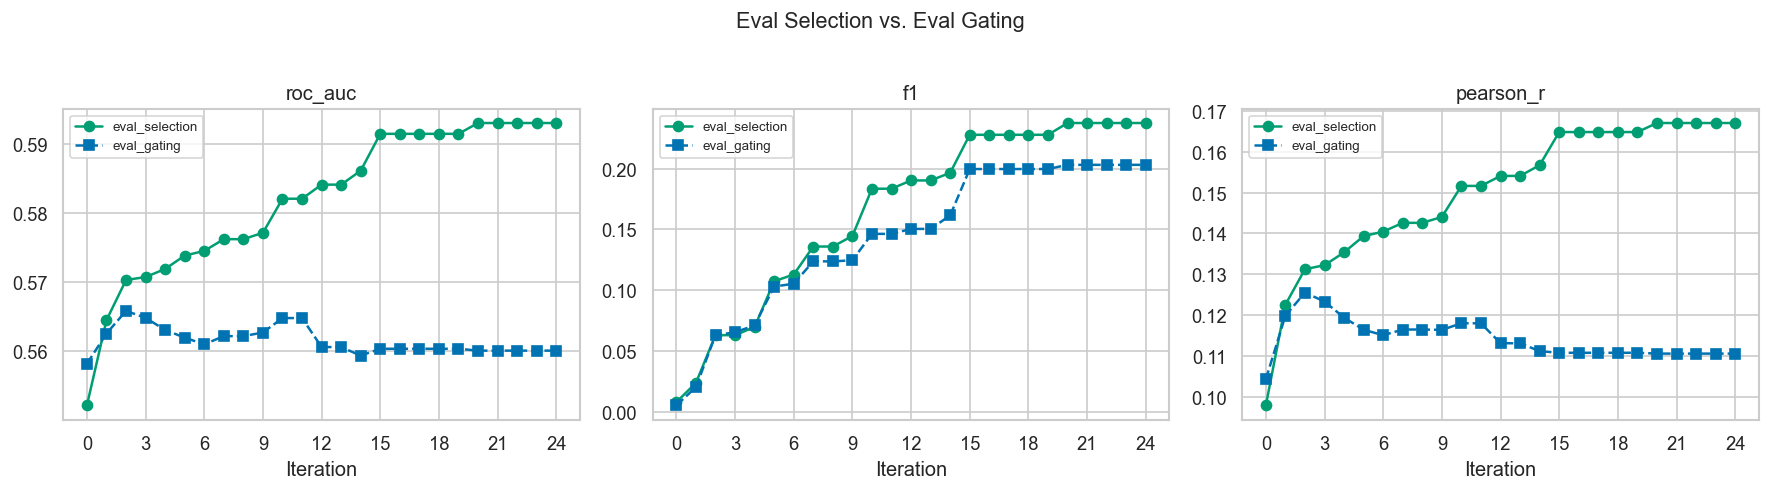

In [119]:
# Extract eval_selection and eval_gating from iterations data
selection_records = []
gating_records = []
for it in iterations:
    sel = it.get("eval_selection", {})
    sel["iteration"] = it["iteration"]
    selection_records.append(sel)
    
    gate = it.get("eval_gating", {})
    gate["iteration"] = it["iteration"]
    gating_records.append(gate)

sel_df = pd.DataFrame(selection_records)
gate_df = pd.DataFrame(gating_records)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["roc_auc", "f1", "pearson_r"]):
    ax.plot(sel_df["iteration"], sel_df[col], "o-", label="eval_selection", color="C2")
    ax.plot(gate_df["iteration"], gate_df[col], "s--", label="eval_gating", color="C0")
    ax.set_title(col)
    ax.set_xlabel("Iteration")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

fig.suptitle("Eval Selection vs. Eval Gating", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## 4. Number of Active Metrics Per Iteration

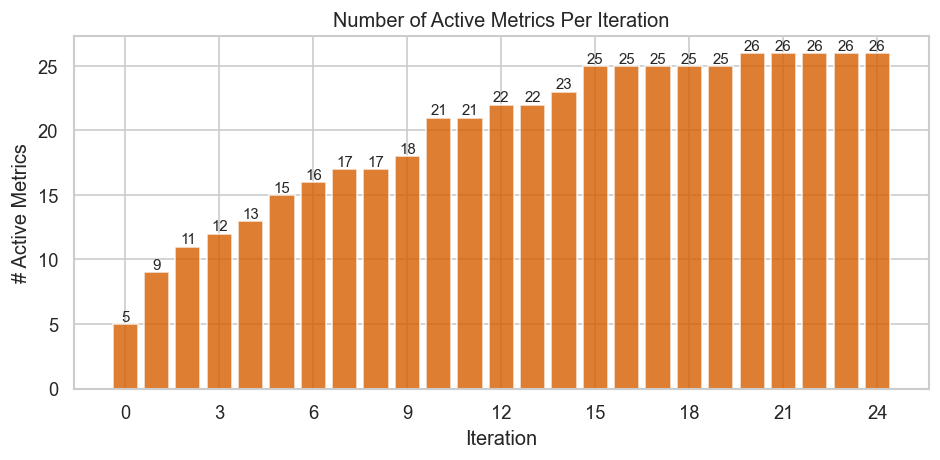

In [120]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    [it["iteration"] for it in iterations],
    [it["num_active_metrics"] for it in iterations],
    color="C3", alpha=0.8
)
ax.set_xlabel("Iteration")
ax.set_ylabel("# Active Metrics")
ax.set_title("Number of Active Metrics Per Iteration")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for it in iterations:
    ax.annotate(str(it["num_active_metrics"]),
                (it["iteration"], it["num_active_metrics"]),
                ha="center", va="bottom", fontsize=9)
fig.tight_layout()
plt.show()

## 5. Metric Coefficient Evolution

How do individual metric weights change as the model refines across iterations?

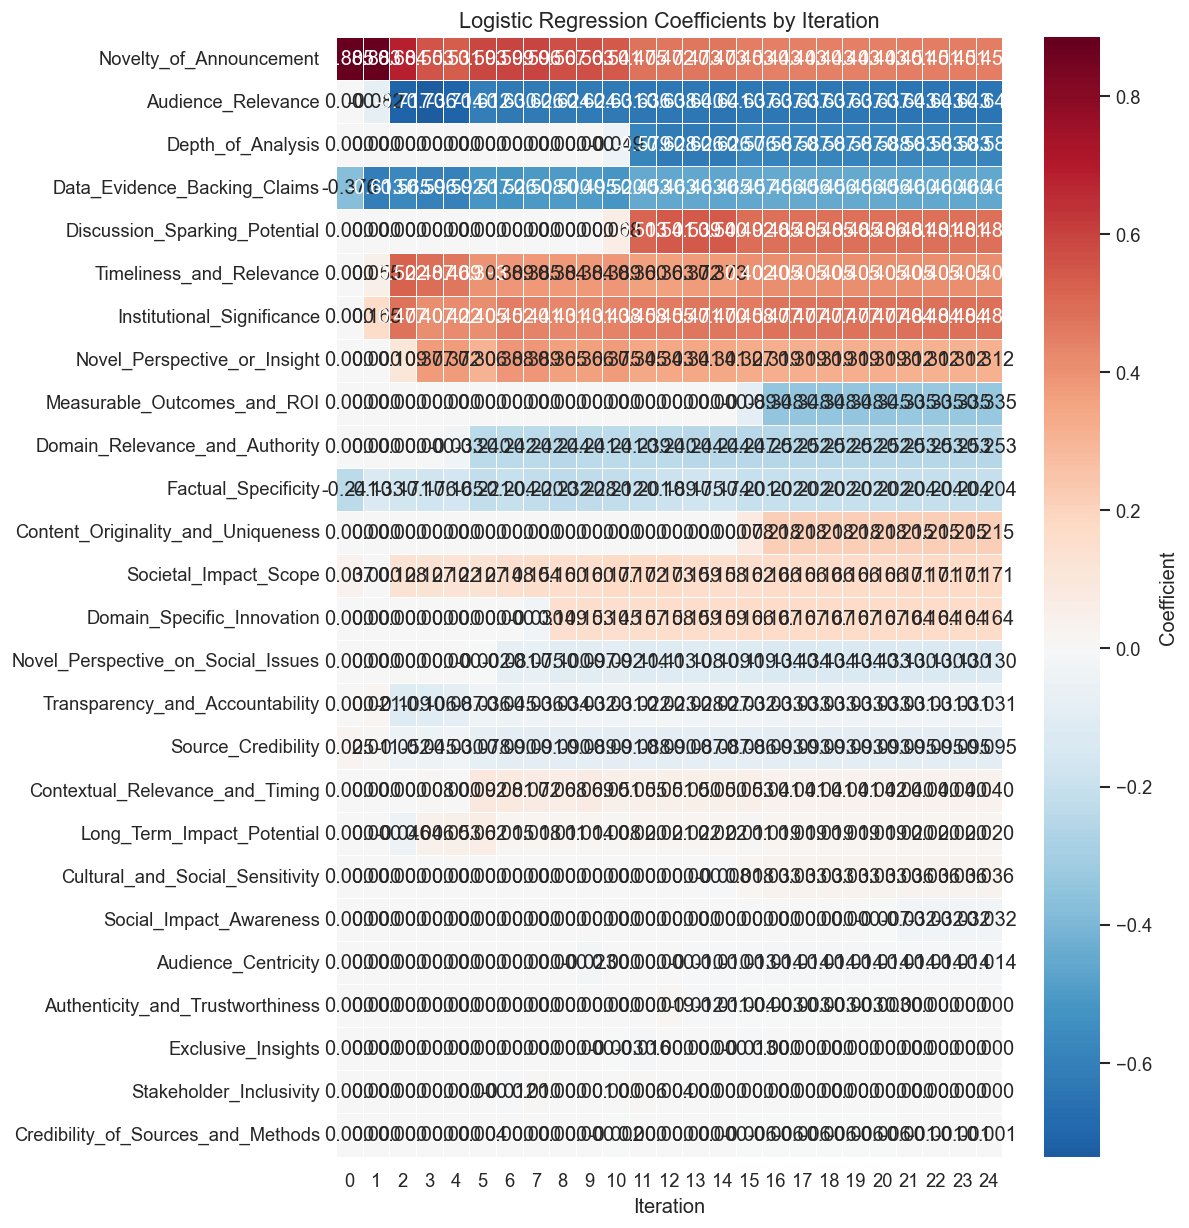

In [121]:
# Pivot coefficients for heatmap
coef_pivot = coefficients_df.pivot_table(
    index="name", columns="iteration", values="coefficient", aggfunc="last"
).fillna(0)

# Sort by absolute max coefficient
coef_pivot = coef_pivot.loc[coef_pivot.abs().max(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, max(6, len(coef_pivot) * 0.4)))
sns.heatmap(
    coef_pivot, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
    linewidths=0.5, ax=ax, cbar_kws={"label": "Coefficient"}
)
ax.set_title("Logistic Regression Coefficients by Iteration", fontsize=13)
ax.set_xlabel("Iteration")
ax.set_ylabel("")
fig.tight_layout()
plt.show()

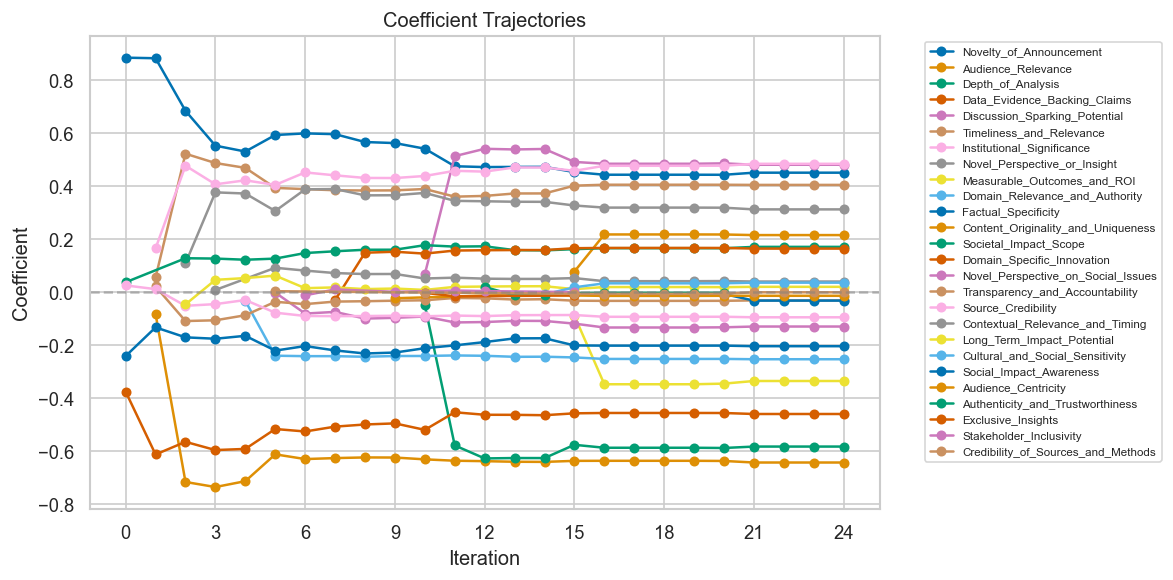

In [122]:
# Line plot for coefficient trajectories
fig, ax = plt.subplots(figsize=(10, 5))
for name in coef_pivot.index:
    vals = coef_pivot.loc[name]
    nonzero = vals[vals != 0]
    if len(nonzero) > 0:
        ax.plot(nonzero.index, nonzero.values, "o-", label=name, markersize=5)

ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Iteration")
ax.set_ylabel("Coefficient")
ax.set_title("Coefficient Trajectories")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
fig.tight_layout()
plt.show()

## 6. Marginal Contributions

Each metric's marginal contribution to the model at each iteration. This tells us which metrics actually improved predictive performance when added.

In [123]:
# Parse marginal contributions from metrics.csv
marginal_records = []
for _, row in metrics_df.iterrows():
    mc_str = row.get("marginal_contributions", "{}")
    if pd.isna(mc_str) or mc_str == "":
        continue
    try:
        mc = json.loads(mc_str.replace("'", '"')) if isinstance(mc_str, str) else mc_str
    except (json.JSONDecodeError, ValueError):
        continue
    for it_str, val in mc.items():
        marginal_records.append({
            "name": row["name"],
            "iteration": int(it_str),
            "marginal_contribution": val
        })

mc_df = pd.DataFrame(marginal_records)
if len(mc_df) > 0:
    mc_pivot = mc_df.pivot_table(
        index="name", columns="iteration", values="marginal_contribution", aggfunc="last"
    ).fillna(0)
    mc_pivot = mc_pivot.loc[mc_pivot.abs().max(axis=1).sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(10, max(6, len(mc_pivot) * 0.4)))
    sns.heatmap(
        mc_pivot, annot=True, fmt=".4f", cmap="RdYlGn", center=0,
        linewidths=0.5, ax=ax, cbar_kws={"label": "Marginal Contribution (ROC-AUC)"}
    )
    ax.set_title("Marginal Contributions by Metric and Iteration", fontsize=13)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("")
    fig.tight_layout()
    plt.show()
else:
    print("No marginal contribution data found.")

No marginal contribution data found.


## 7. Gating Decisions & Churn

Which iterations were accepted? How much metric churn (fraction of metrics replaced) occurred?

In [124]:
gate_info = []
for it in iterations:
    gate_info.append({
        "iteration": it["iteration"],
        "accepted": it.get("accepted", None),
        "gate_score (roc_auc)": it.get("eval_gate_score", None),
        "num_active_metrics": it.get("num_active_metrics", None),
        "churn": it.get("churn", 0.0),
        "method": it.get("mismatch_stats", {}).get("method", it.get("method", "seed")),
        "pairs": it.get("mismatch_stats", {}).get("pairs", None),
        "data_points": it.get("mismatch_stats", {}).get("points", None),
    })

gate_df_display = pd.DataFrame(gate_info)
gate_df_display

,iteration,accepted,gate_score (roc_auc),num_active_metrics,churn,method,pairs,data_points
0,0,True,0.558184,5,0.0,seed,5,10
1,1,True,0.562555,9,0.0,exact,5,10
2,2,True,0.565828,11,0.0,exact,5,10
3,3,True,0.564815,12,0.0,exact,5,10
4,4,True,0.563069,13,0.0,exact,5,10
5,5,True,0.561959,15,0.0,exact,5,10
6,6,True,0.560991,16,0.0,exact,5,10
7,7,True,0.562176,17,0.0,exact,5,10
8,8,False,0.562176,17,0.0,exact,5,10
9,9,True,0.562701,18,0.0,exact,5,10


## 8. Generated Metrics & Rubrics

All metrics discovered by the pipeline, with their rubrics and lifecycle.

In [125]:
for _, row in metrics_df.iterrows():
    name = row["name"]
    born = row["born_iteration"]
    active = row.get("active_iterations", [])
    retired = row.get("retired_iteration", None)
    rubric = row.get("rubric_text", "")
    
    status = "ACTIVE" if pd.isna(retired) or retired is None else f"RETIRED (iter {int(retired)})"
    
    print(f"{'='*80}")
    print(f"METRIC: {name}")
    print(f"  Born: iteration {born} | Active: {active} | Status: {status}")
    if rubric and len(str(rubric)) > 10:
        print(f"  Rubric:")
        lines = str(rubric).strip().split("\n")
        for line in lines[:2]:
            print(f"    {line.strip()}")
        if len(lines) > 2:
            print(f"    ... ({len(lines) - 2} more levels)")
    else:
        print(f"  Rubric: (not available — metrics.csv from different run)")
    print()

METRIC: Factual_Specificity
  Born: iteration 0 | Active: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24] | Status: ACTIVE
  Rubric:
    1: The press release lacks specific facts and data to support its claims. The information provided is vague or general.
    2: The press release provides some general information, but lacks specific details or data to support its claims.
    ... (3 more levels)

METRIC: Societal_Impact_Scope
  Born: iteration 0 | Active: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24] | Status: ACTIVE
  Rubric:
    1: The press release addresses a very narrow or specialized topic with little to no broader societal impact.
    2: The press release addresses a topic of some relevance to a specific group or community, but its impact is limited.
    ... (3 more levels)

METRIC: Source_Credibility
  Born: iteration 0 | Active: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17,

## 9. Active Metrics Timeline

Visualize which metrics were active at each iteration.

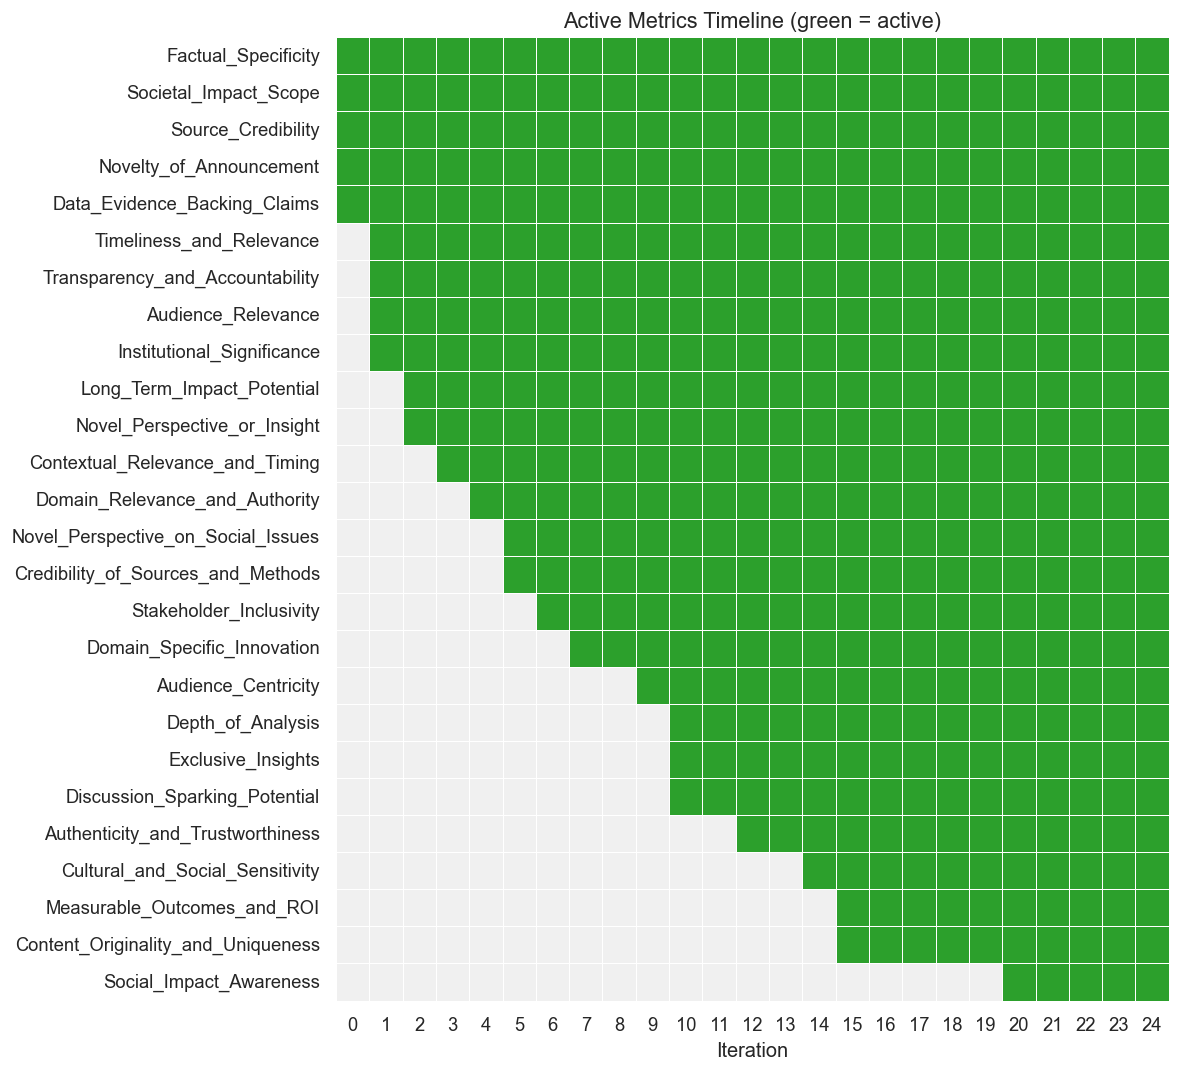

In [126]:
# Build a matrix: metric_name x iteration -> active (1) or not (0)
all_metric_names = []
for it in iterations:
    for name in it.get("active_metric_names", []):
        if name not in all_metric_names:
            all_metric_names.append(name)

iter_nums = [it["iteration"] for it in iterations]
timeline = pd.DataFrame(0, index=all_metric_names, columns=iter_nums)

for it in iterations:
    for name in it.get("active_metric_names", []):
        timeline.loc[name, it["iteration"]] = 1

fig, ax = plt.subplots(figsize=(10, max(5, len(all_metric_names) * 0.35)))
sns.heatmap(
    timeline, cmap=["#f0f0f0", "#2ca02c"], linewidths=0.5,
    cbar=False, ax=ax, annot=False
)
ax.set_title("Active Metrics Timeline (green = active)", fontsize=13)
ax.set_xlabel("Iteration")
ax.set_ylabel("")
fig.tight_layout()
plt.show()

## 10. Final Model Summary

The final iteration's metric weights, sorted by absolute magnitude.

Final iteration: 24
Number of active metrics: 26



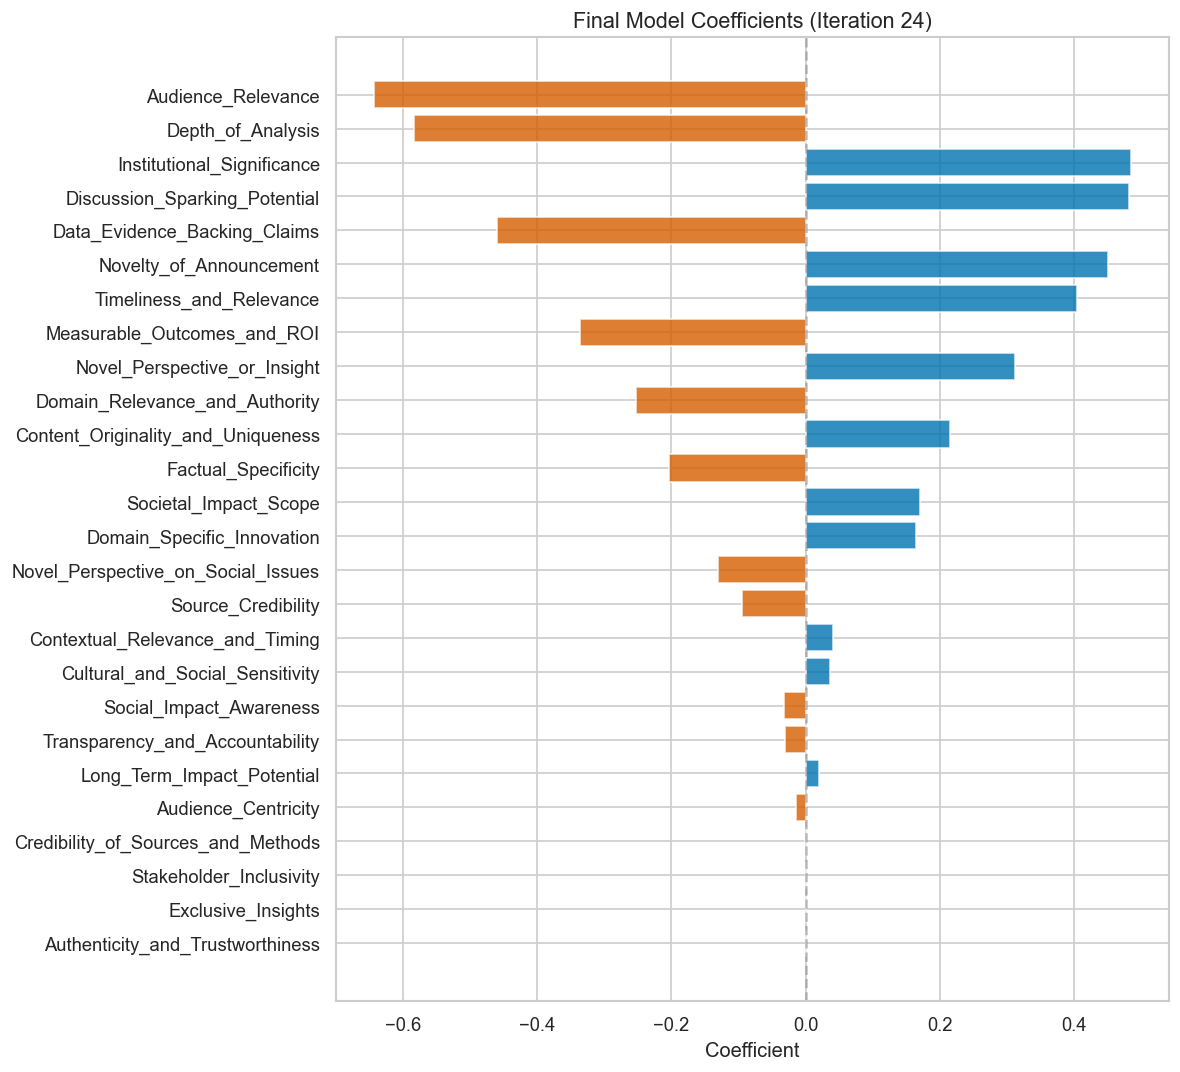

,name,coefficient
0,Audience_Relevance,-0.643154
1,Depth_of_Analysis,-0.582959
2,Institutional_Significance,0.484415
3,Discussion_Sparking_Potential,0.480834
4,Data_Evidence_Backing_Claims,-0.459993
5,Novelty_of_Announcement,0.450917
6,Timeliness_and_Relevance,0.404754
7,Measurable_Outcomes_and_ROI,-0.335442
8,Novel_Perspective_or_Insight,0.312373
9,Domain_Relevance_and_Authority,-0.253321


In [127]:
final_iter = coefficients_df["iteration"].max()
final_coefs = coefficients_df[coefficients_df["iteration"] == final_iter].copy()
final_coefs["abs_coefficient"] = final_coefs["coefficient"].abs()
final_coefs = final_coefs.sort_values("abs_coefficient", ascending=False)

print(f"Final iteration: {final_iter}")
print(f"Number of active metrics: {len(final_coefs)}")
print()

fig, ax = plt.subplots(figsize=(10, max(4, len(final_coefs) * 0.35)))
colors = ["C0" if c >= 0 else "C3" for c in final_coefs["coefficient"]]
ax.barh(final_coefs["name"], final_coefs["coefficient"], color=colors, alpha=0.8)
ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Coefficient")
ax.set_title(f"Final Model Coefficients (Iteration {final_iter})", fontsize=13)
ax.invert_yaxis()
fig.tight_layout()
plt.show()

final_coefs[["name", "coefficient"]].reset_index(drop=True)

## 10b. Interaction Terms Analysis

Pairwise interaction terms (metric A x metric B) are included as features in the L1 regression.
L1 selects which interactions have non-zero coefficients. Each active interaction is named by the
LLM to describe what the combination captures.

Found 3377 interaction records across 25 iterations
Unique interactions: 244


,iteration,interaction,metric_a,metric_b,coefficient,description
0,0,Factual_Specificity × Societal_Impact_Scope,Factual_Specificity,Societal_Impact_Scope,0.407801,The combination of Factual_Specificity and Soc...
1,0,Factual_Specificity × Source_Credibility,Factual_Specificity,Source_Credibility,-0.109031,The combination of Factual_Specificity and Sou...
2,0,Factual_Specificity × Novelty_of_Announcement,Factual_Specificity,Novelty_of_Announcement,-0.125468,The combination of Factual_Specificity and Nov...
3,0,Factual_Specificity × Data_Evidence_Backing_Cl...,Factual_Specificity,Data_Evidence_Backing_Claims,0.055279,The combination of Factual_Specificity and Dat...
4,0,Societal_Impact_Scope × Novelty_of_Announcement,Societal_Impact_Scope,Novelty_of_Announcement,-0.503549,The combination of Societal_Impact_Scope and N...
...,...,...,...,...,...,...
3372,24,Authenticity_and_Trustworthiness × Measurable_...,Authenticity_and_Trustworthiness,Measurable_Outcomes_and_ROI,-0.025946,The combination of Authenticity_and_Trustworth...
3373,24,Authenticity_and_Trustworthiness × Content_Ori...,Authenticity_and_Trustworthiness,Content_Originality_and_Uniqueness,0.026594,The combination of Authenticity_and_Trustworth...
3374,24,Cultural_and_Social_Sensitivity × Measurable_O...,Cultural_and_Social_Sensitivity,Measurable_Outcomes_and_ROI,-0.008720,The combination of Cultural_and_Social_Sensiti...
3375,24,Cultural_and_Social_Sensitivity × Content_Orig...,Cultural_and_Social_Sensitivity,Content_Originality_and_Uniqueness,0.015693,The combination of Cultural_and_Social_Sensiti...


/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_55658/3630854425.py:44: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


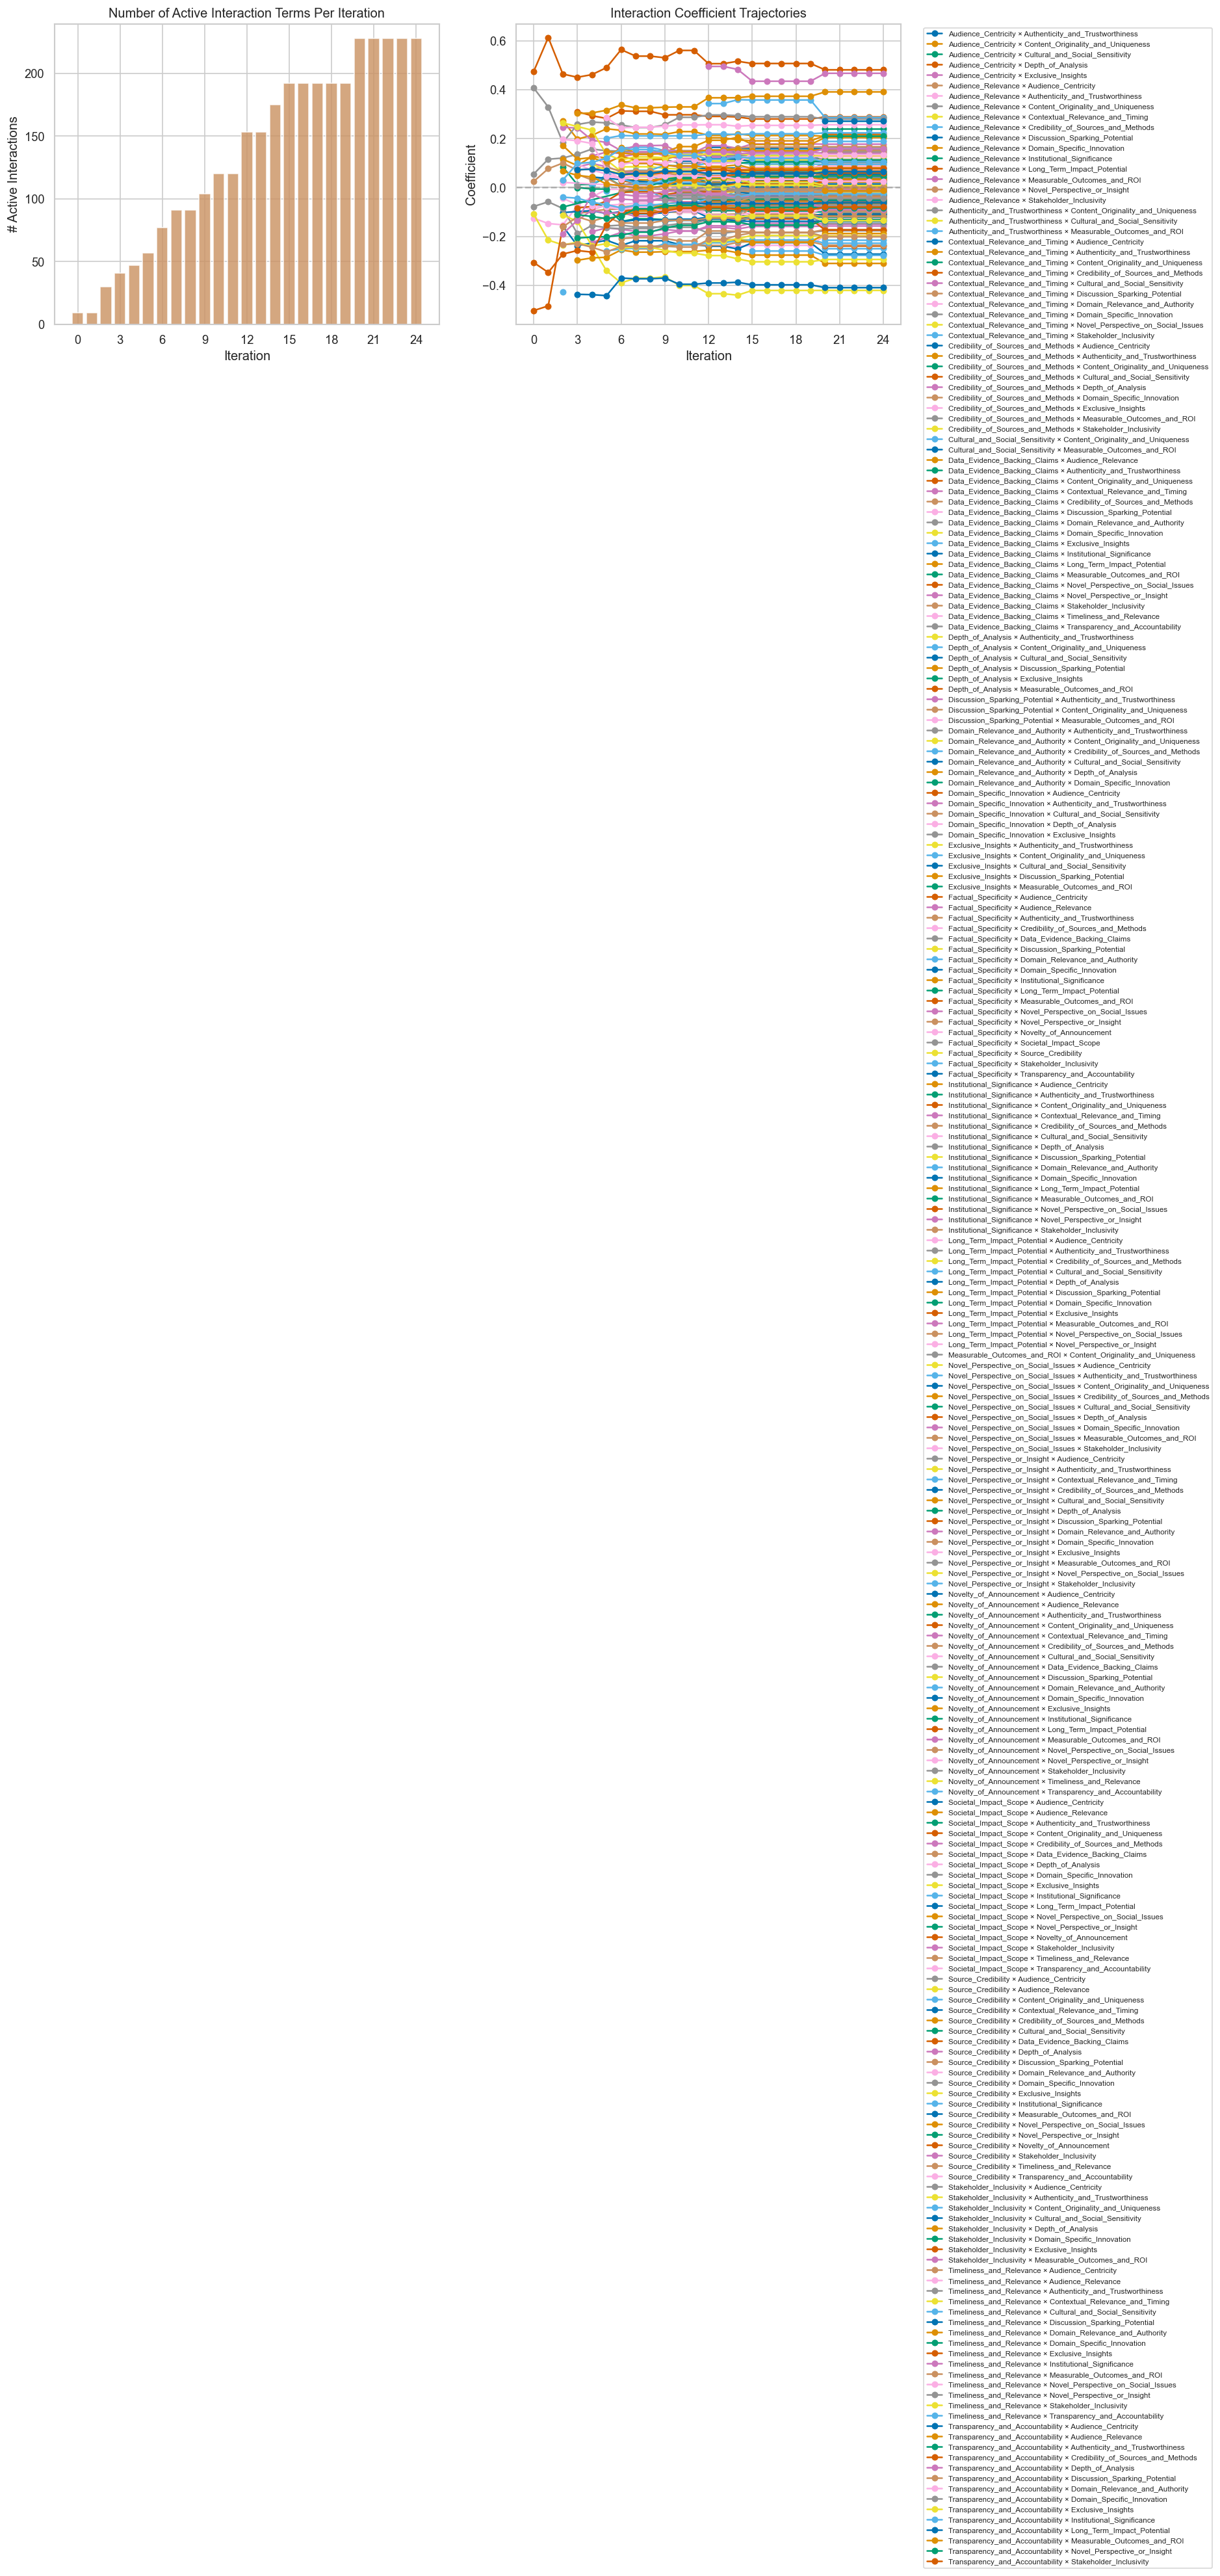


Active Interaction Descriptions (latest iteration):

  Factual_Specificity × Societal_Impact_Scope
    Coef: 0.2798
    Description: The combination of Factual_Specificity and Societal_Impact_Scope captures the press release's ability to substantiate a broadly relevant and impactful topic with concrete evidence, conveying a meaningful and credible message that resonates with a wide audience.

  Factual_Specificity × Source_Credibility
    Coef: -0.4209
    Description: The combination of Factual_Specificity and Source_Credibility metrics captures the overall trustworthiness and persuasive power of a press release, conveying the extent to which the specific, detailed information provided is backed by a reliable and expert source, thereby enhancing the release's credibility and newsworthiness.

  Factual_Specificity × Novelty_of_Announcement
    Coef: -0.0517
    Description: The combination of Factual_Specificity and Novelty_of_Announcement captures the press release's ability to intro

In [128]:
# Extract interaction terms from iterations.jsonl
interaction_records = []
for it in iterations:
    ai = it.get("active_interactions", {})
    for col_name, info in ai.items():
        interaction_records.append({
            "iteration": it["iteration"],
            "interaction": col_name,
            "metric_a": info.get("a", ""),
            "metric_b": info.get("b", ""),
            "coefficient": info.get("coef", 0.0),
            "description": info.get("desc", ""),
        })

if interaction_records:
    inter_df = pd.DataFrame(interaction_records)
    print(f"Found {len(inter_df)} interaction records across {inter_df['iteration'].nunique()} iterations")
    print(f"Unique interactions: {inter_df['interaction'].nunique()}")
    display(inter_df)

    # Number of active interactions per iteration
    inter_count = inter_df.groupby("iteration").size().reset_index(name="n_interactions")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: count of active interactions per iteration
    ax = axes[0]
    ax.bar(inter_count["iteration"], inter_count["n_interactions"], color="C5", alpha=0.8)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("# Active Interactions")
    ax.set_title("Number of Active Interaction Terms Per Iteration")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    # Right: interaction coefficient evolution
    ax = axes[1]
    for name, grp in inter_df.groupby("interaction"):
        short = name.replace("inter__", "").replace("__x__", " × ")
        ax.plot(grp["iteration"], grp["coefficient"], "o-", label=short, markersize=5)
    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Coefficient")
    ax.set_title("Interaction Coefficient Trajectories")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    fig.tight_layout()
    plt.show()

    # Display interaction descriptions
    print("\nActive Interaction Descriptions (latest iteration):")
    latest_iter = inter_df["iteration"].max()
    latest = inter_df[inter_df["iteration"] == latest_iter]
    for _, row in latest.iterrows():
        print(f"\n  {row['metric_a']} × {row['metric_b']}")
        print(f"    Coef: {row['coefficient']:.4f}")
        print(f"    Description: {row['description']}")
else:
    print("No interaction terms found in this run.")
    print("Interaction terms were added after this run started.")
    print("Re-run with --no-interactions=False (default) to generate interaction data.")

In [129]:
# Show the top interactions by absolute coefficient at each iteration
if interaction_records:
    inter_df = pd.DataFrame(interaction_records)
    
    # Top interactions at the best-performing iteration
    if len(am_test) > 0 if 'am_test' in dir() else False:
        best_iter = int(am_test.loc[am_test["roc_auc"].idxmax(), "iteration"])
    else:
        # Use iteration with highest test AUC
        test_aucs = {it["iteration"]: it.get("test", {}).get("roc_auc", 0) for it in iterations}
        best_iter = max(test_aucs, key=test_aucs.get)
    
    best_interactions = inter_df[inter_df["iteration"] == best_iter].copy()
    best_interactions["abs_coef"] = best_interactions["coefficient"].abs()
    best_interactions = best_interactions.sort_values("abs_coef", ascending=False)
    
    print(f"Top 15 interactions at best iteration ({best_iter}):")
    print(f"{'Metric A':>30} × {'Metric B':<30} {'Coef':>8}")
    print("-" * 75)
    for _, row in best_interactions.head(15).iterrows():
        print(f"{row['metric_a']:>30} × {row['metric_b']:<30} {row['coefficient']:>8.3f}")
    
    # Heatmap: metric pair interaction strengths at best iteration
    metric_names_at_best = sorted(set(
        best_interactions["metric_a"].tolist() + best_interactions["metric_b"].tolist()
    ))
    n = len(metric_names_at_best)
    if n > 0 and n <= 15:
        heatmap = pd.DataFrame(0.0, index=metric_names_at_best, columns=metric_names_at_best)
        for _, row in best_interactions.iterrows():
            heatmap.loc[row["metric_a"], row["metric_b"]] = row["coefficient"]
            heatmap.loc[row["metric_b"], row["metric_a"]] = row["coefficient"]
        
        fig, ax = plt.subplots(figsize=(10, 8))
        mask = np.triu(np.ones_like(heatmap, dtype=bool), k=0)
        sns.heatmap(
            heatmap, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, ax=ax, cbar_kws={"label": "Interaction Coefficient"},
            xticklabels=[n[:15] for n in metric_names_at_best],
            yticklabels=[n[:15] for n in metric_names_at_best],
        )
        ax.set_title(f"Interaction Coefficient Heatmap (Iteration {best_iter})", fontsize=13)
        fig.tight_layout()
        plt.show()
    elif n > 15:
        print(f"\n(Too many metrics ({n}) for heatmap — showing top interactions only)")
else:
    print("No interaction data available.")

Top 15 interactions at best iteration (24):
                      Metric A × Metric B                           Coef
---------------------------------------------------------------------------
            Source_Credibility × Data_Evidence_Backing_Claims      0.482
            Source_Credibility × Depth_of_Analysis                 0.468
           Factual_Specificity × Source_Credibility               -0.421
         Societal_Impact_Scope × Long_Term_Impact_Potential       -0.410
  Data_Evidence_Backing_Claims × Long_Term_Impact_Potential        0.391
    Institutional_Significance × Long_Term_Impact_Potential       -0.311
       Novelty_of_Announcement × Timeliness_and_Relevance         -0.294
            Audience_Relevance × Long_Term_Impact_Potential        0.289
  Data_Evidence_Backing_Claims × Exclusive_Insights                0.286
           Factual_Specificity × Societal_Impact_Scope             0.280
      Timeliness_and_Relevance × Cultural_and_Social_Sensitivity   -0.277
  D

## 11. Contrastive Pairs Analysis

What methods were used to generate contrastive pairs at each iteration?

    iteration method  count
0           0   seed      5
1           1  exact      5
2           2  exact      5
3           3  exact      5
4           4  exact      5
5           5  exact      5
6           6  exact      5
7           7  exact      5
8           8  exact      5
9           9  exact      5
10         10  exact      5
11         11  exact      5
12         12  exact      5
13         13  exact      5
14         14  exact      5
15         15  exact      5
16         16  exact      5
17         17  exact      5
18         18  exact      5
19         19  exact      5
20         20  exact      5
21         21  exact      5
22         22  exact      5
23         23  exact      5
24         24  exact      5


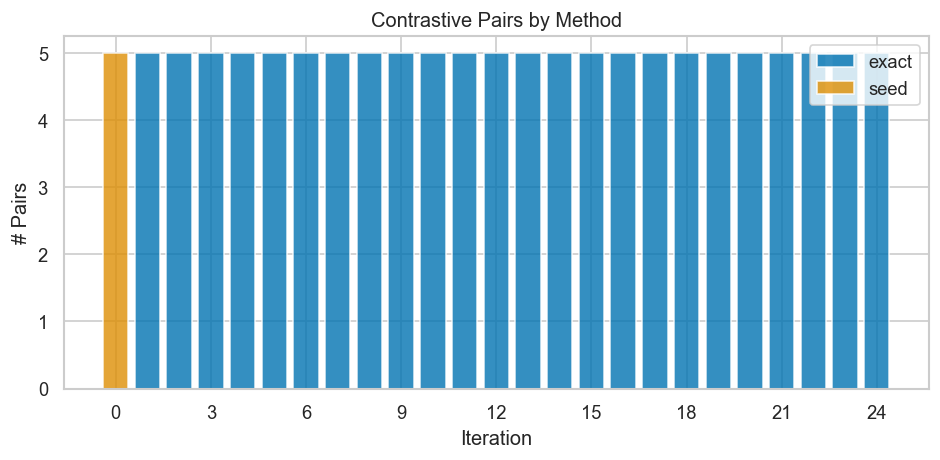

In [130]:
pair_summary = pairs_deduped.groupby(["iteration", "method"]).size().reset_index(name="count")
print(pair_summary)

fig, ax = plt.subplots(figsize=(8, 4))
for method, grp in pair_summary.groupby("method"):
    ax.bar(grp["iteration"], grp["count"], label=method, alpha=0.8)
ax.set_xlabel("Iteration")
ax.set_ylabel("# Pairs")
ax.set_title("Contrastive Pairs by Method")
ax.legend()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
fig.tight_layout()
plt.show()

## 11b. Training Samples & Data Sizes Per Iteration

How many labeled training samples were used for propensity matching at each iteration?

 iteration  train_labeled_n  train_accuracy  eval_selection_n  eval_gating_n  test_n
         0               10             NaN             36901           9226     100
         1              200        0.530000             36901           9226     100
         2              200        0.535000             36901           9226     100
         3              200        0.530000             36901           9226     100
         4              400        0.552500             36901           9226     100
         5              400        0.557500             36901           9226     100
         6              400        0.557500             36901           9226     100
         7              400        0.555000             36901           9226     100
         8              600        0.550000             36901           9226     100
         9              600        0.550000             36901           9226     100
        10              600        0.553333             36901    

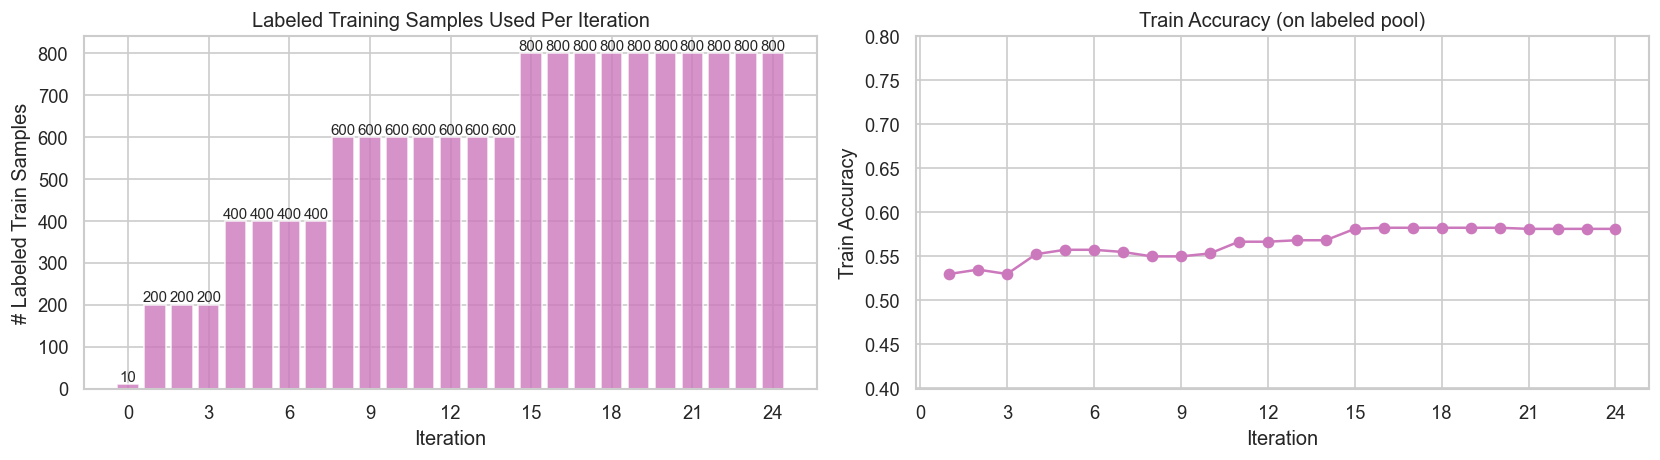

In [131]:
# Extract train_assessed.n and data_sizes from iterations
train_info = []
for it in iterations:
    ta = it.get("train_assessed", {})
    ds = it.get("data_sizes", {})
    train_info.append({
        "iteration": it["iteration"],
        "train_labeled_n": ta.get("n", 0),
        "train_accuracy": ta.get("accuracy", float("nan")),
        "eval_selection_n": ds.get("eval_selection", 0),
        "eval_gating_n": ds.get("eval_gating", 0),
        "test_n": ds.get("test", 0),
    })

train_info_df = pd.DataFrame(train_info)
print(train_info_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: labeled train samples per iteration
ax = axes[0]
ax.bar(train_info_df["iteration"], train_info_df["train_labeled_n"], color="C4", alpha=0.8)
ax.set_xlabel("Iteration")
ax.set_ylabel("# Labeled Train Samples")
ax.set_title("Labeled Training Samples Used Per Iteration")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for _, row in train_info_df.iterrows():
    ax.annotate(str(int(row["train_labeled_n"])),
                (row["iteration"], row["train_labeled_n"]),
                ha="center", va="bottom", fontsize=9)

# Right: train accuracy per iteration
ax = axes[1]
valid = train_info_df.dropna(subset=["train_accuracy"])
valid = valid[valid["train_accuracy"].notna() & (valid["train_labeled_n"] > 0)]
if len(valid) > 0:
    ax.plot(valid["iteration"], valid["train_accuracy"], "o-", color="C4")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Train Accuracy")
    ax.set_title("Train Accuracy (on labeled pool)")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.set_ylim(0.4, 0.8)
else:
    ax.text(0.5, 0.5, "No train accuracy data", ha="center", va="center", transform=ax.transAxes)

fig.tight_layout()
plt.show()

## 11c. Rubric Prompt Length Analysis

Each metric's rubric is the text prompt used to score documents (5-level descriptions, 1–5).
Tracking rubric length over iterations helps detect prompt bloat.

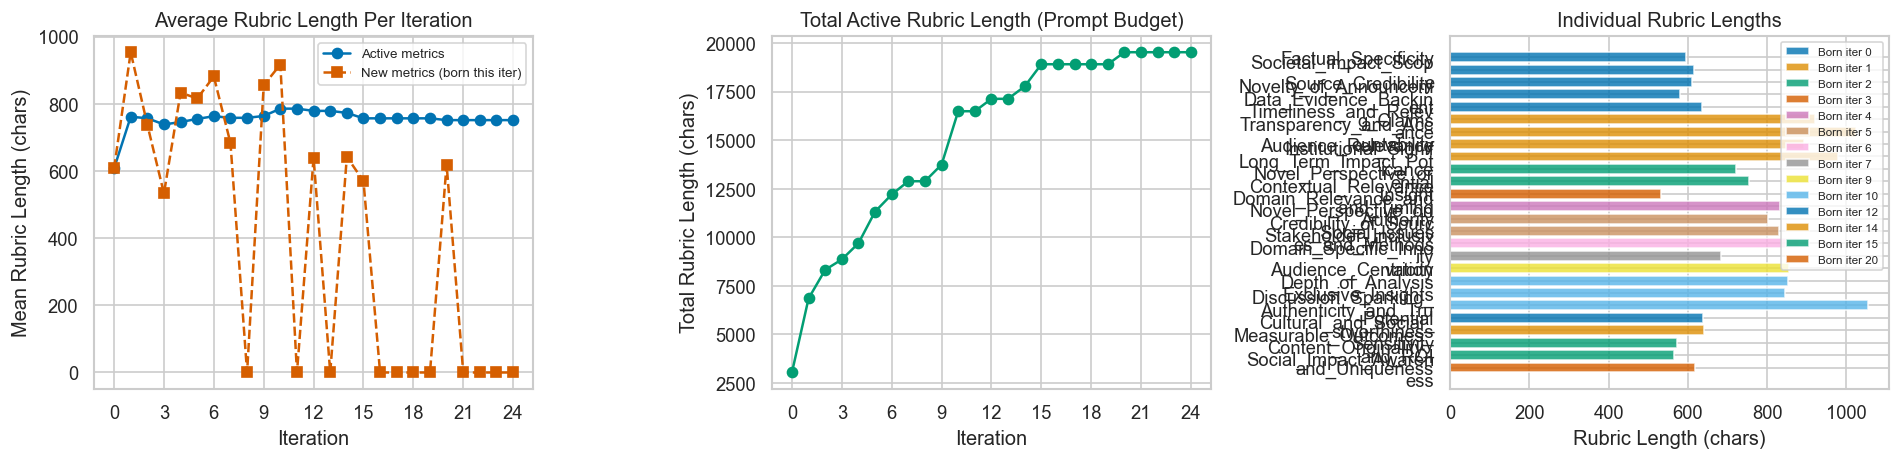


Rubric Length Summary:
Iter | # Active | Mean Len | Total Len | # New | New Mean Len
------------------------------------------------------------
   0 |        5 |      607 |      3037 |     5 |          607
   1 |        9 |      761 |      6850 |     4 |          953
   2 |       11 |      757 |      8325 |     2 |          738
   3 |       12 |      738 |      8858 |     1 |          533
   4 |       13 |      745 |      9691 |     1 |          833
   5 |       15 |      755 |     11322 |     2 |          816
   6 |       16 |      763 |     12203 |     1 |          881
   7 |       17 |      758 |     12886 |     1 |          683
   8 |       17 |      758 |     12886 |     0 |            0
   9 |       18 |      763 |     13741 |     1 |          855
  10 |       21 |      785 |     16491 |     3 |          917
  11 |       21 |      785 |     16491 |     0 |            0
  12 |       22 |      779 |     17130 |     1 |          639
  13 |       22 |      779 |     17130 |     0 

In [132]:
# Compute rubric lengths per metric
metrics_df["rubric_length"] = metrics_df["rubric_text"].astype(str).str.len()

# active_iterations is already a list (from iterations.jsonl parsing above)
# No need to parse from string
iter_nums = sorted(set(it["iteration"] for it in iterations))
avg_rubric_accepted = []
avg_rubric_new = []

for it_num in iter_nums:
    # Active metrics at this iteration
    active_mask = metrics_df["active_iterations"].apply(lambda x: it_num in x)
    active_lengths = metrics_df.loc[active_mask, "rubric_length"]
    avg_rubric_accepted.append({
        "iteration": it_num,
        "mean_rubric_len": active_lengths.mean() if len(active_lengths) > 0 else 0,
        "total_rubric_len": active_lengths.sum() if len(active_lengths) > 0 else 0,
        "n_active": len(active_lengths),
    })

    # New metrics born at this iteration
    new_mask = metrics_df["born_iteration"] == it_num
    new_lengths = metrics_df.loc[new_mask, "rubric_length"]
    avg_rubric_new.append({
        "iteration": it_num,
        "mean_rubric_len": new_lengths.mean() if len(new_lengths) > 0 else 0,
        "n_new": len(new_lengths),
    })

accepted_df = pd.DataFrame(avg_rubric_accepted)
new_df = pd.DataFrame(avg_rubric_new)

# Only plot rubric analysis if we have rubric text
has_rubrics = metrics_df["rubric_length"].max() > 10

if has_rubrics:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    ax = axes[0]
    ax.plot(accepted_df["iteration"], accepted_df["mean_rubric_len"], "o-", color="C0", label="Active metrics")
    ax.plot(new_df["iteration"], new_df["mean_rubric_len"], "s--", color="C3", label="New metrics (born this iter)")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Mean Rubric Length (chars)")
    ax.set_title("Average Rubric Length Per Iteration")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    ax = axes[1]
    ax.plot(accepted_df["iteration"], accepted_df["total_rubric_len"], "o-", color="C2")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Total Rubric Length (chars)")
    ax.set_title("Total Active Rubric Length (Prompt Budget)")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    ax = axes[2]
    for born_it in sorted(metrics_df["born_iteration"].unique()):
        subset = metrics_df[metrics_df["born_iteration"] == born_it]
        ax.barh(
            [fill(n, 20) for n in subset["name"]],
            subset["rubric_length"],
            label=f"Born iter {born_it}",
            alpha=0.8,
        )
    ax.set_xlabel("Rubric Length (chars)")
    ax.set_title("Individual Rubric Lengths")
    ax.legend(fontsize=7)
    ax.invert_yaxis()

    fig.tight_layout()
    plt.show()
else:
    print("Note: Rubric text not available for current run metrics.")
    print("metrics.csv contains rubrics from a different run.")
    print("Rubric length analysis requires matching metric names.")

# Print summary table
print("\nRubric Length Summary:")
print(f"{'Iter':>4} | {'# Active':>8} | {'Mean Len':>8} | {'Total Len':>9} | {'# New':>5} | {'New Mean Len':>12}")
print("-" * 60)
for a, n in zip(avg_rubric_accepted, avg_rubric_new):
    print(f"{a['iteration']:>4} | {a['n_active']:>8} | {a['mean_rubric_len']:>8.0f} | {a['total_rubric_len']:>9} | {n['n_new']:>5} | {n['mean_rubric_len']:>12.0f}")

## 12. Summary Table

In [133]:
summary_rows = []
for it in iterations:
    row = {
        "iteration": it["iteration"],
        "num_metrics": it["num_active_metrics"],
        "method": it.get("mismatch_stats", {}).get("method", "seed"),
        "accepted": it.get("accepted", True),
        "gate_roc_auc": it.get("eval_gate_score"),
        "eval_sel_roc_auc": it.get("eval_selection", {}).get("roc_auc"),
        "eval_gate_roc_auc": it.get("eval_gating", {}).get("roc_auc"),
        "test_roc_auc": it.get("test", {}).get("roc_auc"),
        "test_f1": it.get("test", {}).get("f1"),
        "test_pearson_r": it.get("test", {}).get("pearson_r"),
        "churn": it.get("churn", 0.0),
        "train_assessed_n": it.get("train_assessed", {}).get("n", 0),
        "train_accuracy": it.get("train_assessed", {}).get("accuracy"),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df.style.format({
    "gate_roc_auc": "{:.4f}",
    "eval_sel_roc_auc": "{:.4f}",
    "eval_gate_roc_auc": "{:.4f}",
    "test_roc_auc": "{:.4f}",
    "test_f1": "{:.4f}",
    "test_pearson_r": "{:.4f}",
    "churn": "{:.3f}",
    "train_accuracy": "{:.3f}",
}).background_gradient(subset=["gate_roc_auc", "eval_sel_roc_auc", "test_roc_auc"], cmap="YlGn")

,iteration,num_metrics,method,accepted,gate_roc_auc,eval_sel_roc_auc,eval_gate_roc_auc,test_roc_auc,test_f1,test_pearson_r,churn,train_assessed_n,train_accuracy
0,0,5,seed,True,0.5582,0.5522,0.5582,0.5184,0.0000,-0.0099,0.000,10,nan
1,1,9,exact,True,0.5626,0.5645,0.5626,0.5177,0.0889,0.0308,0.000,200,0.530
2,2,11,exact,True,0.5658,0.5703,0.5658,0.4327,0.0816,-0.0515,0.000,200,0.535
3,3,12,exact,True,0.5648,0.5707,0.5648,0.4514,0.1200,-0.0317,0.000,200,0.530
4,4,13,exact,True,0.5631,0.5719,0.5631,0.4439,0.1200,-0.0443,0.000,400,0.552
5,5,15,exact,True,0.5620,0.5738,0.5620,0.4596,0.1200,-0.0123,0.000,400,0.557
6,6,16,exact,True,0.5610,0.5745,0.5610,0.4476,0.0816,-0.0328,0.000,400,0.557
7,7,17,exact,True,0.5622,0.5762,0.5622,0.4357,0.1176,-0.0490,0.000,400,0.555
8,8,17,exact,False,0.5622,0.5762,0.5622,0.4357,0.1176,-0.0490,0.000,600,0.550
9,9,18,exact,True,0.5627,0.5771,0.5627,0.4308,0.1176,-0.0609,0.000,600,0.550


## 13. Key Observations

In [134]:
# Quick stats for the run
print("=" * 60)
print("RUN SUMMARY")
print("=" * 60)
print(f"Model: meta-llama/Llama-3.3-70B-Instruct (VLLM offline)")
print(f"Task: {config.get('target_measure', 'N/A')} prediction")
print(f"Configured iterations: {config.get('num_iterations', 'N/A')}")
print(f"Completed iterations: {len(iterations)} (0..{iterations[-1]['iteration']})")
print(f"Total unique metrics generated: {len(metrics_df)}")
print(f"Final active metrics: {iterations[-1]['num_active_metrics']}")
print(f"k_pairs per iteration: {config.get('k_pairs', 'N/A')}")
print()
final = iterations[-1]
print("PERFORMANCE (final iteration):")
for split_name, split_key in [("Eval Selection", "eval_selection"), ("Eval Gating", "eval_gating"), ("Test", "test")]:
    d = final.get(split_key, {})
    if d:
        print(f"  {split_name}:")
        print(f"    ROC-AUC: {d.get('roc_auc', 'N/A'):.4f}  |  F1: {d.get('f1', 'N/A'):.4f}  |  Acc: {d.get('accuracy', 'N/A'):.4f}")
print()
best_test_auc = max(it.get("test", {}).get("roc_auc", 0) for it in iterations)
best_test_iter = max(range(len(iterations)), key=lambda i: iterations[i].get("test", {}).get("roc_auc", 0))
print(f"Best test ROC-AUC: {best_test_auc:.4f} (iteration {iterations[best_test_iter]['iteration']})")

RUN SUMMARY
Model: meta-llama/Llama-3.3-70B-Instruct (VLLM offline)
Task: newsworthiness_score prediction
Configured iterations: 25
Completed iterations: 25 (0..24)
Total unique metrics generated: 26
Final active metrics: 26
k_pairs per iteration: 5

PERFORMANCE (final iteration):
  Eval Selection:
    ROC-AUC: 0.5930  |  F1: 0.2377  |  Acc: 0.5907
  Eval Gating:
    ROC-AUC: 0.5601  |  F1: 0.2033  |  Acc: 0.5751
  Test:
    ROC-AUC: 0.5337  |  F1: 0.0687  |  Acc: 0.5750

Best test ROC-AUC: 0.5337 (iteration 24)


---

# Part 2: Metric Tree Analysis

The Metric Tree builds a hierarchical classifier. The root node proposes metrics and
fits a logistic regression. Misclassified examples are routed to child nodes that
propose **exception metrics** to handle the residual errors.

**Output dir**: `outputs/metric_tree/press_release_70b/`

In [135]:
# --- Metric Tree: Load Results ---
import sys
sys.path.insert(0, str(Path("../methods/autometrics").resolve()))
sys.path.insert(0, str(Path("../methods").resolve()))

MT_OUTPUT_DIR = Path("../outputs/metric_tree/press_release_70b")
assert MT_OUTPUT_DIR.exists(), f"Metric tree output not found: {MT_OUTPUT_DIR}"

# Load results
with open(MT_OUTPUT_DIR / "results.json") as f:
    mt_results = json.load(f)

mt_complexity = pd.read_csv(MT_OUTPUT_DIR / "tree_complexity.csv")
mt_predictions = pd.read_csv(MT_OUTPUT_DIR / "test_predictions.csv")

# Load tree summary text
mt_summary_text = (MT_OUTPUT_DIR / "tree_summary.txt").read_text()

print("=== Metric Tree Results ===")
print(json.dumps(mt_results, indent=2))

=== Metric Tree Results ===
{
  "test_accuracy": 0.5305135008584361,
  "articulability_gap": {
    "root_accuracy": 0.5305135008584361,
    "tree_accuracy": 0.5305135008584361,
    "articulability_gap": 0.0,
    "per_depth_accuracy": {
      "0": 0.5305135008584361
    },
    "n_examples": 12814
  },
  "n_trees": 1,
  "n_nodes": 1,
  "n_metrics": 5,
  "config": {
    "max_depth": 2,
    "min_subset_size": 20,
    "n_metrics_to_propose": 5,
    "use_interactions": true,
    "use_learned_router": false,
    "random_seed": 42
  }
}


## MT.1 Tree Structure & Summary

In [136]:
# Print the tree summary
print(mt_summary_text)

METRIC TREE SUMMARY
Task: Evaluate press releases for newsworthiness as judged by journalists. A newsworthy press release has genuine news value: it introduces a significant development, contains verifiable claims backed by co
Total nodes: 1
Total unique metrics: 5

[root] depth=0
  Train acc: 0.527 | Eval acc: 0.522
  Points: 102504 | Confidence threshold: 0.500
  Features (5):
    - Evidence_Quality
    - Societal_Impact_Scope
    - Source_Credibility
    - Novelty_and_Timeliness
    - Audience_Relevance
  Local metrics (5):
    [40bad38b] Evidence_Quality (scale=ordinal)
      Rubric: 1: The press release lacks any concrete evidence or data to support its claims. 2: The press release provides some anecdotal evidence or limited data,...
    [e0dadb1c] Societal_Impact_Scope (scale=ordinal)
      Rubric: 1: The press release has little to no impact on society, and its relevance is limited to a small group or niche audience. 2: The press release has som...
    [67877f71] Source_Credibil

In [137]:
# Tree complexity table
print("\n=== Tree Complexity ===")
display(mt_complexity)

print(f"\nTotal nodes: {mt_results['n_nodes']}")
print(f"Total unique metrics: {mt_results['n_metrics']}")
print(f"Test accuracy: {mt_results['test_accuracy']:.4f}")
print(f"Articulability gap: {mt_results['articulability_gap']['articulability_gap']:.4f}")


=== Tree Complexity ===


,node_id,depth,parent_id,n_local_metrics,n_all_metrics,n_features,n_points,n_correct,train_accuracy,eval_accuracy,n_children,confidence_threshold,n_interactions
0,root,0,NaN,5,5,5,102504,54013,0.526936,0.521736,0,0.5,10



Total nodes: 1
Total unique metrics: 5
Test accuracy: 0.5305
Articulability gap: 0.0000


## MT.2 Tree Visualization

Visualize the tree structure: which metrics are at each node, their coefficients,
and how the tree branches on false positives vs false negatives.

In [138]:
# Try to reconstruct visual tree from the summary data
# Since we don't have the pickled tree object, we parse tree_complexity.csv
# and tree_summary.txt

# Parse metrics and coefficients from tree summary
import re

def parse_tree_summary(text):
    """Parse tree_summary.txt into structured data for visualization."""
    nodes = []
    current_node = None
    current_metrics = []
    current_coefs = {}
    current_interactions = []

    for line in text.split("\n"):
        # Node header
        m = re.match(r"\s*\[(.+?)\] depth=(\d+)", line)
        if m:
            if current_node:
                nodes.append({
                    "node_id": current_node,
                    "metrics": current_metrics,
                    "coefs": current_coefs,
                    "interactions": current_interactions,
                })
            current_node = m.group(1)
            current_metrics = []
            current_coefs = {}
            current_interactions = []

        # Metric line: [hash] Name (scale=...)
        m = re.match(r"\s*\[([a-f0-9]+)\] (.+?) \(scale=(.+?)\)", line)
        if m:
            current_metrics.append({"id": m.group(1), "name": m.group(2), "scale": m.group(3)})

        # Coefficient line
        m = re.match(r"\s*Coef (.+?): ([\-\d\.]+)", line)
        if m:
            current_coefs[m.group(1)] = float(m.group(2))

        # Interaction line
        m = re.match(r"\s+(.+?) x (.+?)$", line)
        if m and "Rubric" not in line:
            current_interactions.append((m.group(1).strip(), m.group(2).strip()))

    if current_node:
        nodes.append({
            "node_id": current_node,
            "metrics": current_metrics,
            "coefs": current_coefs,
            "interactions": current_interactions,
        })

    return nodes

parsed_nodes = parse_tree_summary(mt_summary_text)
print(f"Parsed {len(parsed_nodes)} nodes from tree summary")
for node in parsed_nodes:
    print(f"\n  Node: {node['node_id']}")
    print(f"    Metrics: {[m['name'] for m in node['metrics']]}")
    print(f"    Coefficients: {node['coefs']}")
    print(f"    Interactions: {len(node['interactions'])}")

Parsed 1 nodes from tree summary

  Node: root
    Metrics: ['Evidence_Quality', 'Societal_Impact_Scope', 'Source_Credibility', 'Novelty_and_Timeliness', 'Audience_Relevance']
    Coefficients: {'Evidence_Quality': -0.035, 'Societal_Impact_Scope': 0.1176, 'Source_Credibility': 0.0591, 'Novelty_and_Timeliness': 0.1487, 'Audience_Relevance': -0.1355}
    Interactions: 10


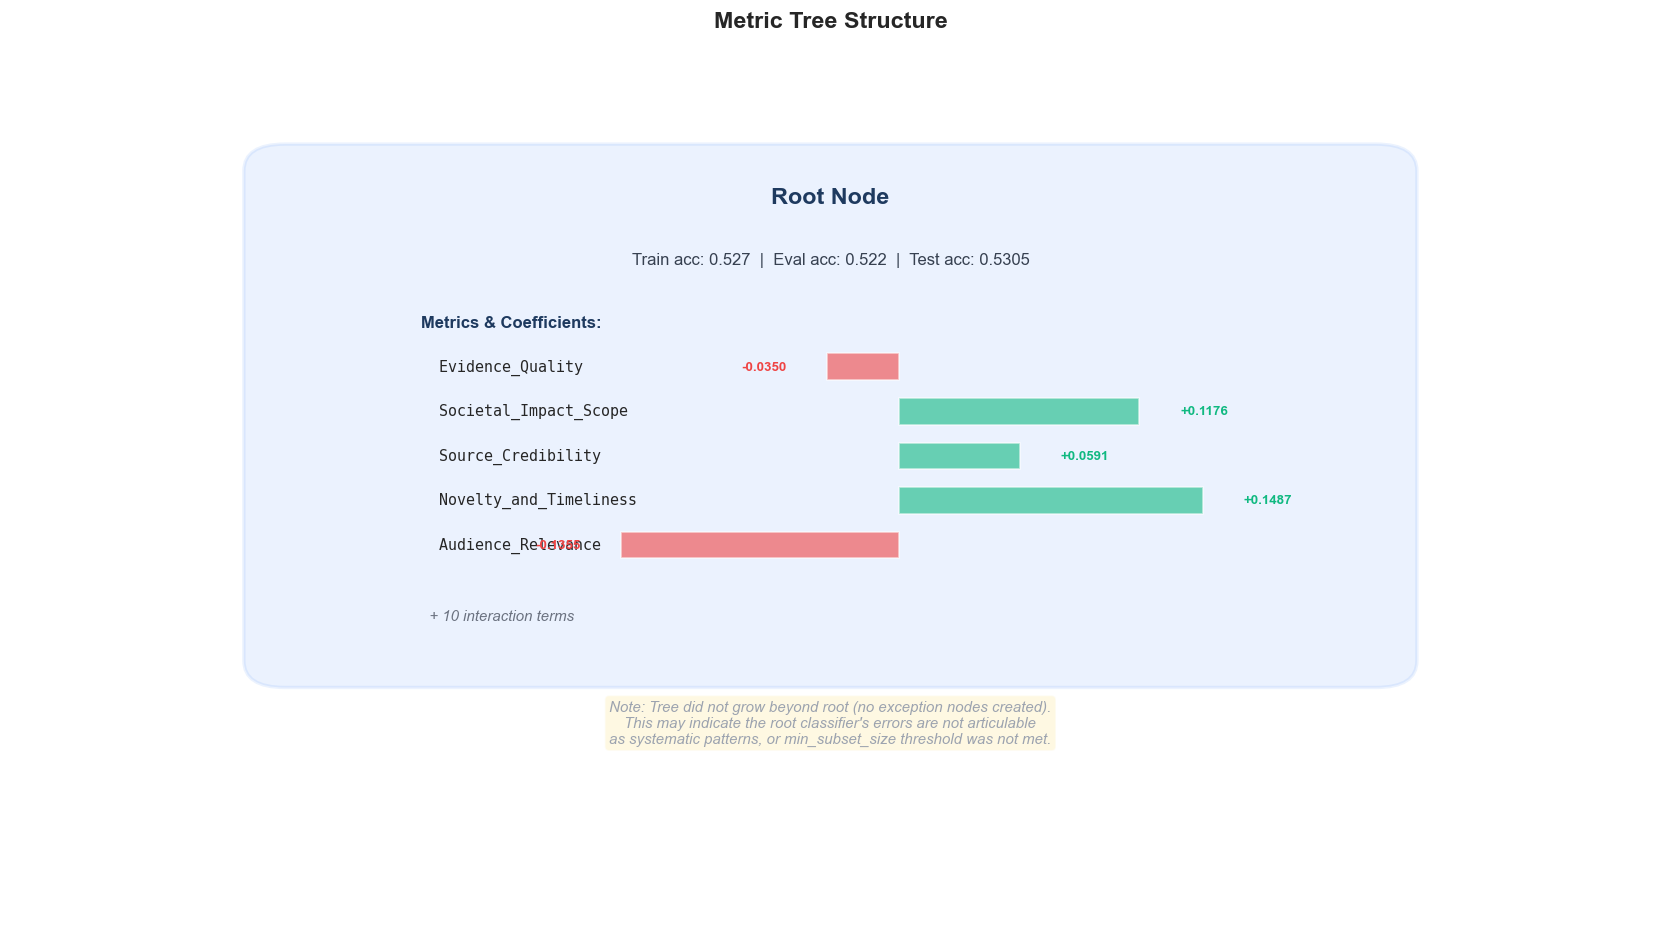

In [139]:
# Visualize tree structure from parsed data
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(-1, 11)
ax.set_ylim(-2, 8)
ax.axis("off")
fig.patch.set_facecolor("white")

if len(parsed_nodes) == 1:
    # Single root node — draw it prominently with full detail
    node = parsed_nodes[0]
    row = mt_complexity.iloc[0] if len(mt_complexity) > 0 else {}

    # Draw large node box
    from matplotlib.patches import FancyBboxPatch
    rect = FancyBboxPatch(
        (1, 1), 8, 5.5,
        boxstyle="round,pad=0.3",
        facecolor="#3B82F6", alpha=0.1,
        edgecolor="#3B82F6", linewidth=2,
    )
    ax.add_patch(rect)

    # Title
    ax.text(5, 6.2, f"Root Node", fontsize=14, fontweight="bold",
            ha="center", va="center", color="#1E3A5F")

    # Accuracy info
    train_acc = row.get("train_accuracy", mt_results.get("test_accuracy", 0))
    eval_acc = row.get("eval_accuracy", 0)
    test_acc = mt_results.get("test_accuracy", 0)
    ax.text(5, 5.5, f"Train acc: {train_acc:.3f}  |  Eval acc: {eval_acc:.3f}  |  Test acc: {test_acc:.4f}",
            fontsize=10, ha="center", va="center", color="#374151")

    # Metrics with coefficients
    y_pos = 4.8
    ax.text(2, y_pos, "Metrics & Coefficients:", fontsize=10, fontweight="bold",
            va="center", color="#1E3A5F")
    y_pos -= 0.5

    for m in node["metrics"]:
        coef = node["coefs"].get(m["name"], 0)
        color = "#10B981" if coef > 0 else "#EF4444"
        bar_len = abs(coef) * 15  # scale for visibility
        ax.barh(y_pos, bar_len if coef > 0 else -bar_len, height=0.3,
                left=5.5, color=color, alpha=0.6)
        ax.text(2, y_pos, f"  {m['name']}", fontsize=9, va="center", fontfamily="monospace")
        ax.text(5.5 + (bar_len + 0.3) * (1 if coef > 0 else -1), y_pos,
                f"{coef:+.4f}", fontsize=8, va="center", ha="left" if coef > 0 else "right",
                color=color, fontweight="bold")
        y_pos -= 0.5

    # Interactions count
    if node["interactions"]:
        y_pos -= 0.3
        ax.text(2, y_pos, f"  + {len(node['interactions'])} interaction terms",
                fontsize=9, va="center", color="#6B7280", style="italic")

    # Note about why tree didn't grow
    ax.text(5, 0.3,
            "Note: Tree did not grow beyond root (no exception nodes created).\n"
            "This may indicate the root classifier's errors are not articulable\n"
            "as systematic patterns, or min_subset_size threshold was not met.",
            fontsize=9, ha="center", va="center", color="#9CA3AF", style="italic",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#FEF3C7", alpha=0.5))

else:
    # Multi-node tree: draw hierarchically
    # Simple layout: root at top, children below
    level_gap = 3.0
    sibling_gap = 4.0
    depth_groups = {}
    for i, node in enumerate(parsed_nodes):
        d = int(mt_complexity.iloc[i]["depth"]) if i < len(mt_complexity) else 0
        depth_groups.setdefault(d, []).append((i, node))

    for depth, group in depth_groups.items():
        n = len(group)
        for j, (idx, node) in enumerate(group):
            x = 5 + (j - (n - 1) / 2) * sibling_gap
            y = 7 - depth * level_gap

            # Draw box
            box_w, box_h = 3.5, 2.0
            rect = FancyBboxPatch(
                (x - box_w/2, y - box_h/2), box_w, box_h,
                boxstyle="round,pad=0.15",
                facecolor=["#3B82F6", "#10B981", "#F59E0B", "#EF4444"][depth % 4],
                alpha=0.12,
                edgecolor=["#3B82F6", "#10B981", "#F59E0B", "#EF4444"][depth % 4],
                linewidth=2,
            )
            ax.add_patch(rect)

            # Node info
            row = mt_complexity.iloc[idx] if idx < len(mt_complexity) else {}
            ax.text(x, y + 0.6, node["node_id"], fontsize=9, fontweight="bold",
                    ha="center", va="center")
            acc = row.get("train_accuracy", 0)
            ax.text(x, y + 0.2, f"acc={acc:.3f}", fontsize=8, ha="center", va="center")

            # Metric names
            metric_names = [m["name"][:20] for m in node["metrics"][:3]]
            for k, mn in enumerate(metric_names):
                ax.text(x, y - 0.2 - k * 0.3, mn, fontsize=7, ha="center",
                        va="center", fontfamily="monospace")

    ax.set_xlim(-1, 11)
    ax.set_ylim(-2, 9)

ax.set_title("Metric Tree Structure", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## MT.3 Metric Complexity Analysis

Analyze the rubrics proposed by the tree: their length, vocabulary complexity,
and how these change with depth.

In [140]:
# Parse full rubric text from tree summary for complexity analysis
# Extract rubric snippets from the ALL METRICS section
rubric_section = mt_summary_text.split("ALL METRICS")[1] if "ALL METRICS" in mt_summary_text else ""

metric_rubrics = {}
current_name = None
current_rubric = []
for line in rubric_section.split("\n"):
    m = re.match(r"\s*\[([a-f0-9]+)\] (.+?) \(source: (.+?), scale=(.+?)\)", line)
    if m:
        if current_name and current_rubric:
            metric_rubrics[current_name] = "\n".join(current_rubric)
        current_name = m.group(2)
        current_rubric = []
    elif current_name and line.strip() and not line.strip().startswith("Rubric:"):
        current_rubric.append(line.strip())

if current_name and current_rubric:
    metric_rubrics[current_name] = "\n".join(current_rubric)

print(f"Extracted rubrics for {len(metric_rubrics)} metrics\n")

# Complexity analysis per metric
complexity_rows = []
for name, rubric in metric_rubrics.items():
    words = rubric.split()
    unique_words = set(w.lower() for w in words)
    sentences = [s.strip() for s in rubric.replace("!", ".").replace("?", ".").split(".") if s.strip()]
    levels = [l for l in rubric.split("\n") if l.strip() and l.strip()[0].isdigit()]

    complexity_rows.append({
        "name": name,
        "rubric_len_chars": len(rubric),
        "rubric_len_words": len(words),
        "n_sentences": len(sentences),
        "n_levels": len(levels),
        "unique_words": len(unique_words),
        "lexical_diversity": len(unique_words) / max(len(words), 1),
        "avg_words_per_level": len(words) / max(len(levels), 1),
    })

complexity_df = pd.DataFrame(complexity_rows)
display(complexity_df.sort_values("rubric_len_words", ascending=False))

Extracted rubrics for 5 metrics



,name,rubric_len_chars,rubric_len_words,n_sentences,n_levels,unique_words,lexical_diversity,avg_words_per_level
4,Societal_Impact_Scope,500,87,5,5,46,0.528736,17.4
3,Audience_Relevance,500,84,5,5,31,0.369048,16.8
0,Novelty_and_Timeliness,499,79,5,5,31,0.392405,15.8
1,Evidence_Quality,500,78,5,5,41,0.525641,15.6
2,Source_Credibility,500,78,5,5,38,0.487179,15.6


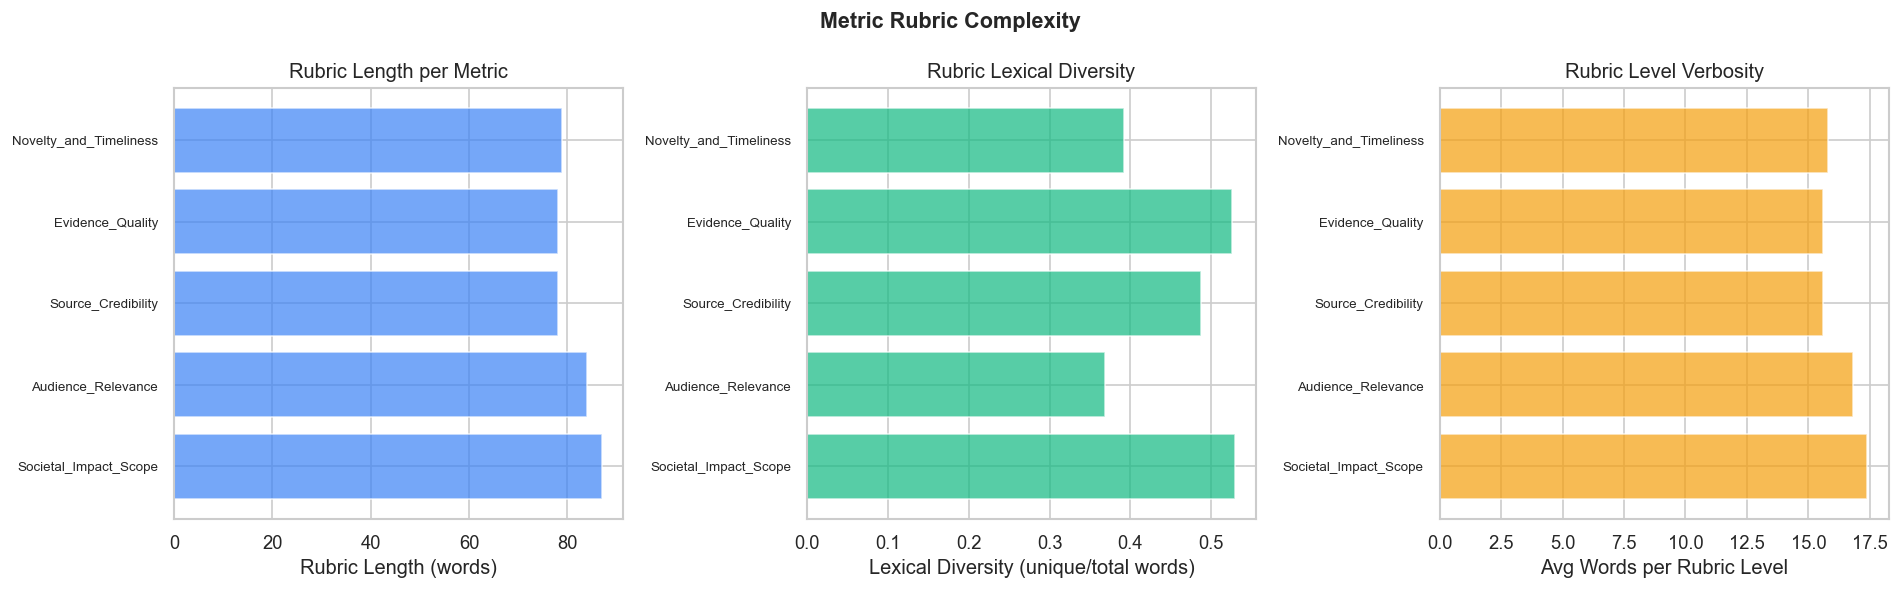

In [141]:
# Visualize rubric complexity
if len(complexity_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Bar chart of rubric lengths
    ax = axes[0]
    names = complexity_df["name"].values
    ax.barh(range(len(names)), complexity_df["rubric_len_words"].values, color="#3B82F6", alpha=0.7)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels([n[:25] for n in names], fontsize=8)
    ax.set_xlabel("Rubric Length (words)")
    ax.set_title("Rubric Length per Metric")
    ax.invert_yaxis()

    # Lexical diversity
    ax = axes[1]
    ax.barh(range(len(names)), complexity_df["lexical_diversity"].values, color="#10B981", alpha=0.7)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels([n[:25] for n in names], fontsize=8)
    ax.set_xlabel("Lexical Diversity (unique/total words)")
    ax.set_title("Rubric Lexical Diversity")
    ax.invert_yaxis()

    # Words per rubric level
    ax = axes[2]
    ax.barh(range(len(names)), complexity_df["avg_words_per_level"].values, color="#F59E0B", alpha=0.7)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels([n[:25] for n in names], fontsize=8)
    ax.set_xlabel("Avg Words per Rubric Level")
    ax.set_title("Rubric Level Verbosity")
    ax.invert_yaxis()

    fig.suptitle("Metric Rubric Complexity", fontsize=13, fontweight="bold")
    fig.tight_layout()
    plt.show()

## MT.4 Test Predictions Analysis

Test predictions: 12814 examples
Unique resolving nodes: ['root']

Prediction distribution:
prediction
1    7771
0    5043
Name: count, dtype: int64

Probability stats:
count    12814.000000
mean         0.501827
std          0.043463
min          0.336178
25%          0.477185
50%          0.514871
75%          0.527195
max          0.634336
Name: probability, dtype: float64


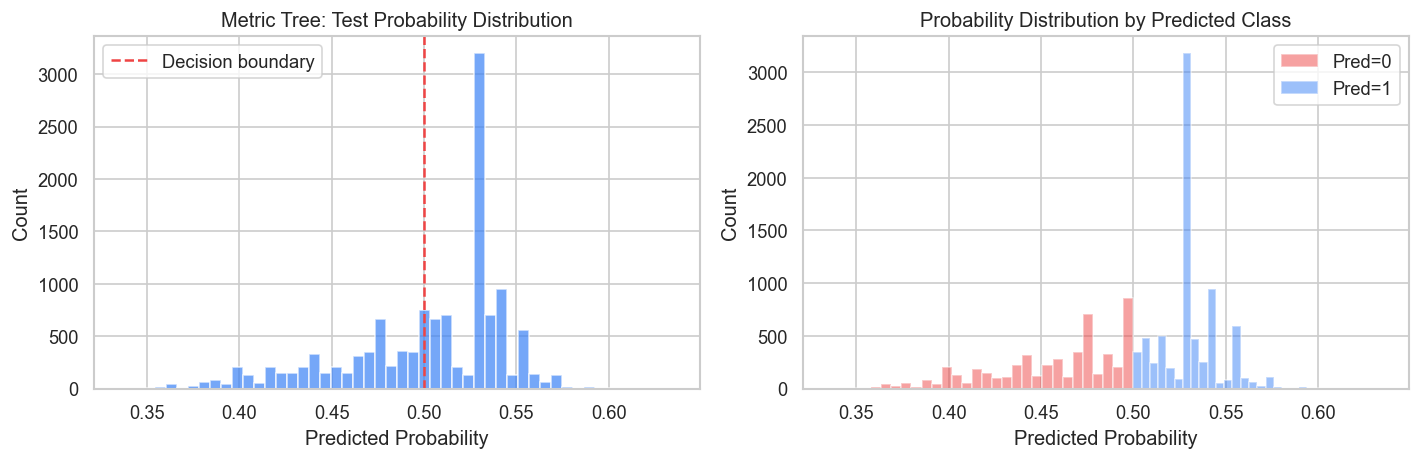

In [142]:
# Analyze test predictions
print(f"Test predictions: {len(mt_predictions)} examples")
print(f"Unique resolving nodes: {mt_predictions['resolving_node'].unique()}")
print(f"\nPrediction distribution:")
print(mt_predictions["prediction"].value_counts())
print(f"\nProbability stats:")
print(mt_predictions["probability"].describe())

# Probability histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(mt_predictions["probability"], bins=50, color="#3B82F6", alpha=0.7, edgecolor="white")
ax.axvline(0.5, color="#EF4444", linestyle="--", label="Decision boundary")
ax.set_xlabel("Predicted Probability")
ax.set_ylabel("Count")
ax.set_title("Metric Tree: Test Probability Distribution")
ax.legend()

# Compare probability distributions by prediction
ax = axes[1]
for pred_val, color, label in [(0, "#EF4444", "Pred=0"), (1, "#3B82F6", "Pred=1")]:
    subset = mt_predictions[mt_predictions["prediction"] == pred_val]
    ax.hist(subset["probability"], bins=30, color=color, alpha=0.5, label=label, edgecolor="white")
ax.set_xlabel("Predicted Probability")
ax.set_ylabel("Count")
ax.set_title("Probability Distribution by Predicted Class")
ax.legend()

fig.tight_layout()
plt.show()

---

## Comparison: Autometrics vs Metric Tree

Side-by-side comparison of the two approaches on the same press release dataset.

In [143]:
# Compare final performance
print("=" * 70)
print("METHOD COMPARISON: Press Release Newsworthiness")
print("=" * 70)
print()

# Autometrics: best iteration performance
best_test_iter_idx = max(range(len(iterations)),
                         key=lambda i: iterations[i].get("test", {}).get("roc_auc", 0))
best_am = iterations[best_test_iter_idx]
final_am = iterations[-1]

print("ITERATIVE AUTOMETRICS (best iteration):")
print(f"  Best test ROC-AUC: {best_am['test']['roc_auc']:.4f} (iter {best_am['iteration']})")
print(f"  Best test accuracy: {best_am['test']['accuracy']:.4f}")
print(f"  Active metrics at best: {best_am['num_active_metrics']}")
print(f"  Final iteration: {final_am['iteration']}")
print(f"  Final test ROC-AUC: {final_am['test']['roc_auc']:.4f}")
print(f"  Final test accuracy: {final_am['test']['accuracy']:.4f}")
print(f"  Final active metrics: {final_am['num_active_metrics']}")
print()

print("METRIC TREE:")
print(f"  Test accuracy: {mt_results['test_accuracy']:.4f}")
print(f"  Root accuracy: {mt_results['articulability_gap']['root_accuracy']:.4f}")
print(f"  Tree accuracy: {mt_results['articulability_gap']['tree_accuracy']:.4f}")
print(f"  Articulability gap: {mt_results['articulability_gap']['articulability_gap']:.4f}")
print(f"  Nodes: {mt_results['n_nodes']}")
print(f"  Metrics: {mt_results['n_metrics']}")
print()

print("OBSERVATIONS:")
print("  Both methods struggle with this task (AUCs near 0.5).")
print("  The metric tree grew only 1 node, suggesting the LLM-proposed")
print("  exception metrics could not improve on the root's errors.")
print("  This aligns with the autometrics result: test AUC plateaus ~0.53-0.59,")
print("  suggesting the 5-level rubric scoring approach may have limited")
print("  discriminative power for press release newsworthiness.")

METHOD COMPARISON: Press Release Newsworthiness

ITERATIVE AUTOMETRICS (best iteration):
  Best test ROC-AUC: 0.5337 (iter 24)
  Best test accuracy: 0.5750
  Active metrics at best: 26
  Final iteration: 24
  Final test ROC-AUC: 0.5337
  Final test accuracy: 0.5750
  Final active metrics: 26

METRIC TREE:
  Test accuracy: 0.5305
  Root accuracy: 0.5305
  Tree accuracy: 0.5305
  Articulability gap: 0.0000
  Nodes: 1
  Metrics: 5

OBSERVATIONS:
  Both methods struggle with this task (AUCs near 0.5).
  The metric tree grew only 1 node, suggesting the LLM-proposed
  exception metrics could not improve on the root's errors.
  This aligns with the autometrics result: test AUC plateaus ~0.53-0.59,
  suggesting the 5-level rubric scoring approach may have limited
  discriminative power for press release newsworthiness.


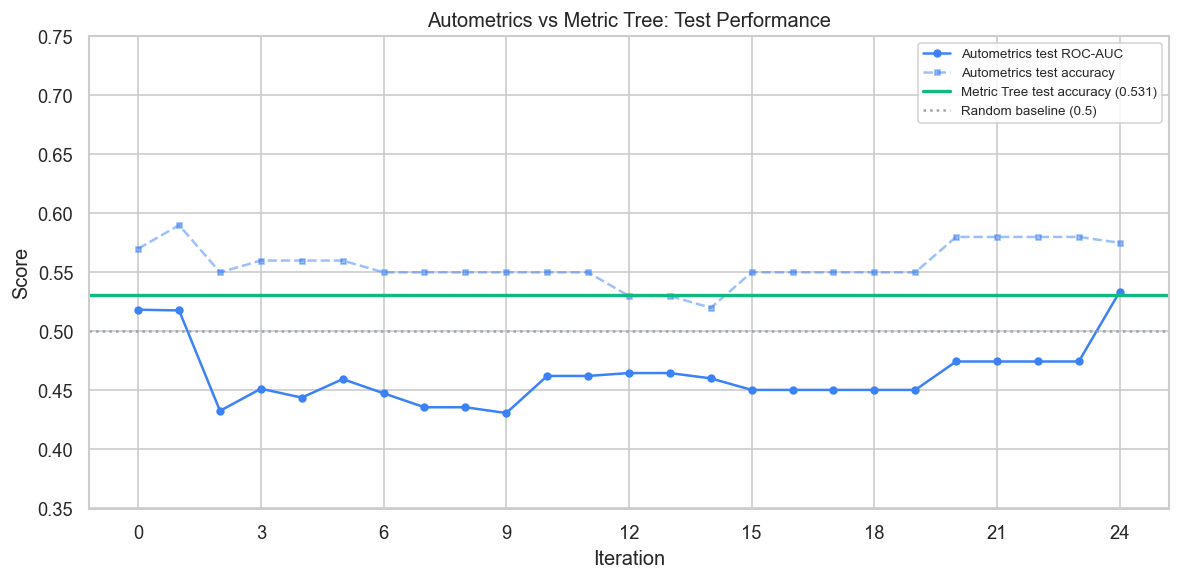

In [144]:
# Plot comparison: Autometrics test AUC over iterations vs Metric Tree
fig, ax = plt.subplots(figsize=(10, 5))

# Autometrics trajectory
am_iters = [it["iteration"] for it in iterations]
am_test_aucs = [it["test"]["roc_auc"] for it in iterations]
am_test_accs = [it["test"]["accuracy"] for it in iterations]

ax.plot(am_iters, am_test_aucs, "o-", color="#3B82F6", label="Autometrics test ROC-AUC", markersize=4)
ax.plot(am_iters, am_test_accs, "s--", color="#3B82F6", alpha=0.5, label="Autometrics test accuracy", markersize=3)

# Metric tree horizontal lines
ax.axhline(mt_results["test_accuracy"], color="#10B981", linestyle="-", linewidth=2,
           label=f"Metric Tree test accuracy ({mt_results['test_accuracy']:.3f})")

# Random baseline
ax.axhline(0.5, color="#9CA3AF", linestyle=":", label="Random baseline (0.5)")

ax.set_xlabel("Iteration")
ax.set_ylabel("Score")
ax.set_title("Autometrics vs Metric Tree: Test Performance")
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylim(0.35, 0.75)

fig.tight_layout()
plt.show()